# Day 8 — Gemini & Claude Model Comparison

Bu notebook'ta daha önce ChatGPT trend serisi üzerinde geliştirilen
Naive, ARIMA, Prophet, XGBoost ve Ensemble modelleri Gemini ce Claude trend
serisine uygulanacaktır.

İlk aşamada model parametreleri yeniden optimize edilmeyecek ve ChatGPT
serisinde seçilen ayarlar doğrudan kullanılacaktır.

Amaç, geliştirilen modelleme yaklaşımının farklı bir trend serisine
genellenip genellenemediğini incelemektir.

In [1]:
# Proje ana klasöründeki src modüllerine eriş

import sys

sys.path.append("..")


# Kullanılacak kütüphaneler

import pandas as pd

from sklearn.model_selection import TimeSeriesSplit


# Daha önce src/forecasting.py içinde oluşturduğumuz fonksiyonlar

from src.forecasting import (
    evaluate_naive_cv,
    evaluate_arima_cv,
    evaluate_prophet_cv,
    evaluate_xgb_recursive_with_change,
    evaluate_ensemble_cv,
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [4]:
# Temizlenmiş Google Trends verisini yükle

data = pd.read_csv(
    "../data/processed/google_trends_ai_3y_clean.csv",
    index_col="date",
    parse_dates=True,
)


# Gemini trend serisini seç
gemini = data["gemini"]


print(gemini.shape)
print(gemini.index[0])
print(gemini.index[-1])


(157,)
2023-07-30 00:00:00
2026-07-26 00:00:00


In [5]:
# XGBoost modelinde kullanılacak geçmiş hafta sayısı

N_LAGS = 8


# Tüm modelleri aynı tarih aralığında karşılaştırabilmek için
# ilk 8 haftayı çıkar

aligned_gemini = gemini.iloc[N_LAGS:]


# Kontrol

print("Shape:", aligned_gemini.shape)
print("İlk tarih:", aligned_gemini.index[0])
print("Son tarih:", aligned_gemini.index[-1])

Shape: (149,)
İlk tarih: 2023-09-24 00:00:00
Son tarih: 2026-07-26 00:00:00


In [6]:
# Gemini için aynı time-series cross-validation yapısını oluştur

tscv_gemini = TimeSeriesSplit(
    n_splits=12,   # Kaç fold kullanıyorduk?
    test_size= 4,  # Her fold'da kaç haftayı test ediyorduk?
)

In [7]:
# Naive modeli Gemini serisi üzerinde değerlendir

naive_gemini = evaluate_naive_cv(
    series= gemini,
    splitter= tscv_gemini,
)

In [8]:
# --------------------------------------------------
# 2. ARIMA(1, 1, 1)
# ChatGPT için seçtiğimiz ARIMA ayarını değiştirmeden kullanıyoruz
# --------------------------------------------------

arima_gemini = evaluate_arima_cv(
    series=aligned_gemini,
    splitter=tscv_gemini,
    order=(1, 1, 1),
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [9]:
# --------------------------------------------------
# 3. Prophet
# ChatGPT için seçtiğimiz cps=1.0 değerini aynen kullanıyoruz
# --------------------------------------------------

prophet_gemini = evaluate_prophet_cv(
    series=aligned_gemini,
    splitter=tscv_gemini,
    changepoint_prior_scale=1.0,
)

11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1] done processing
11:37:38 - cmdstanpy - INFO - Chain [1] start processing
11:37:38 - cmdstanpy - INFO - Chain [1]

In [10]:
# --------------------------------------------------
# Ortalama hata değerlerini hesapla
# --------------------------------------------------

naive_gemini_mae = naive_gemini["MAE"].mean()
naive_gemini_rmse = naive_gemini["RMSE"].mean()

arima_gemini_mae = arima_gemini["MAE"].mean()
arima_gemini_rmse = arima_gemini["RMSE"].mean()

prophet_gemini_mae = prophet_gemini["MAE"].mean()
prophet_gemini_rmse = prophet_gemini["RMSE"].mean()


print(
    "Naive:",
    naive_gemini_mae,
    naive_gemini_rmse,
)

print(
    "ARIMA:",
    arima_gemini_mae,
    arima_gemini_rmse,
)

print(
    "Prophet:",
    prophet_gemini_mae,
    prophet_gemini_rmse,
)

Naive: 7.895833333333333 8.650290942856756
ARIMA: 6.5822791197230295 7.402561030811056
Prophet: 11.277955653448045 12.122209802688573


In [11]:
# --------------------------------------------------
# Gemini için 8 lag oluştur
# --------------------------------------------------

lag_data_gemini = pd.DataFrame(
    {
        "target": gemini,

        **{
            f"lag_{i}": gemini.shift(i)
            for i in range(1, N_LAGS + 1)
        },
    }
)


# İlk 8 haftada yeterli geçmiş olmadığı için
# oluşan NaN satırlarını kaldır

lag_data_gemini = lag_data_gemini.dropna()


# --------------------------------------------------
# Son haftalardaki değişimi modele ayrıca göster
# --------------------------------------------------

lag_data_gemini["change_1"] = (
    lag_data_gemini["lag_1"]
    - lag_data_gemini["lag_2"]
)

lag_data_gemini["change_2"] = (
    lag_data_gemini["lag_2"]
    - lag_data_gemini["lag_3"]
)


# --------------------------------------------------
# X = modelin baktığı bilgiler
# y = modelin tahmin etmeye çalıştığı gerçek değer
# --------------------------------------------------

X_gemini = lag_data_gemini[
    [
        *[
            f"lag_{i}"
            for i in range(1, N_LAGS + 1)
        ],
        "change_1",
        "change_2",
    ]
]

y_gemini = lag_data_gemini["target"]


print("X shape:", X_gemini.shape)
print("y shape:", y_gemini.shape)

X shape: (149, 10)
y shape: (149,)


In [12]:
# --------------------------------------------------
# Tuned XGBoost'u Gemini üzerinde değerlendir
# --------------------------------------------------

xgb_gemini = evaluate_xgb_recursive_with_change(
    X=X_gemini,
    y=y_gemini,
    splitter=tscv_gemini,
)


xgb_gemini_mae = xgb_gemini["MAE"].mean()
xgb_gemini_rmse = xgb_gemini["RMSE"].mean()


print("XGBoost MAE:", xgb_gemini_mae)
print("XGBoost RMSE:", xgb_gemini_rmse)

XGBoost MAE: 10.883868038654327
XGBoost RMSE: 11.870638136508754


Evet, **ChatGPT sonuçlarına kıyasla belirgin biçimde daha kötü**. Ama burada asıl önemli olan “rakamlar büyüdü” değil, **hangi modelin baseline’ı geçebildiği**.

Gemini sonuçların:

```text
Model      MAE      RMSE
ARIMA      6.582    7.403   ← en iyi
Naive      7.896    8.650
XGBoost   10.884   11.871
Prophet   11.278   12.122
```

Burada ilk çıkarım çok net:

> **ChatGPT için çok iyi çalışan Prophet ve XGBoost ayarları Gemini’ye doğrudan taşınınca iyi genellenmemiş.**

Hatta ikisi de Naive’dan kötü. Bu önemli. Çünkü Naive çok basit şekilde “son değer civarında devam eder” diyor. Eğer daha karmaşık model Naive’dan kötü kalıyorsa, o modelin bu haliyle Gemini için faydalı olduğunu söyleyemeyiz.

Ama **ARIMA tam tersine iyi genellenmiş**:

```text
Naive MAE = 7.896
ARIMA MAE = 6.582
```

Yani ARIMA, Naive’a göre hatayı yaklaşık **%17 azaltıyor**. Bu gayet anlamlı bir iyileşme.

Buradan çok değerli bir veri analisti sonucu çıkıyor:

> **“Bir modelin bir zaman serisinde en iyi olması, başka bir zaman serisinde de en iyi olacağı anlamına gelmez.”**

ChatGPT’te:

```text
Prophet > XGBoost > ARIMA > Naive
```

gibi bir sıralamamız vardı.

Gemini’de ise şu an:

```text
ARIMA > Naive > XGBoost > Prophet
```

oldu. Bu neredeyse tersine dönmüş durumda.

Bu bize Gemini serisinin ChatGPT serisinden farklı davrandığını düşündürüyor. Mesela ChatGPT için seçtiğimiz `Prophet cps=1.0` Gemini’de fazla esnek kalıyor olabilir. XGBoost için seçtiğimiz `8 lag + change + depth=2 + 300 tree` yapısı da Gemini’nin geçmiş hareketleriyle gelecek arasındaki ilişkiyi iyi yakalayamıyor olabilir. Bunlar şu an **hipotez**; fold’lara ve serinin grafiğine bakmadan kesin neden diyemeyiz.

Bir de `MAE=6.58 iyi mi kötü mü?` meselesi var. Gemini için tek başına `6.58`e bakıp kötü demem. Çünkü Gemini’nin kendisi daha oynaksa tahmin etmek doğal olarak daha zor olabilir. En doğru kıyas baseline:

```text
Naive 7.90
ARIMA 6.58
```

Dolayısıyla **ARIMA şu an Gemini için işe yarayan bir model**.

Prophet’in `11.28` ve XGBoost’un `10.88` olması ise bu halleriyle gerçekten kötü; özellikle Naive’ın çok üstünde oldukları için.

Şimdi bence tuning’e atlamayalım. Önce planladığımız **50/50 Prophet + XGBoost ensemble’ı Gemini’de de aynen çalıştıralım**. Ben muhtemelen ARIMA’yı geçmesini beklemiyorum çünkü iki bileşen de tek başına kötü çıktı; ama birbirlerinin ters yönlü hatalarını dengeliyorlarsa şaşırtabilir. Bu testi yapmadan “ensemble Gemini’de çalışmadı” diyemeyiz.

Sonra fold bazında neden ARIMA’nın öne çıktığını inceleyelim. Bu Day 8’in asıl öğretici kısmı olacak.


In [13]:
# --------------------------------------------------
# Prophet + XGBoost ensemble modelini Gemini'de test et
# --------------------------------------------------

ensemble_gemini = evaluate_ensemble_cv(
    series=aligned_gemini,
    X=X_gemini,
    y=y_gemini,
    splitter=tscv_gemini,
    prophet_weight=0.5,
    xgb_weight=0.5,
)


# --------------------------------------------------
# Ensemble modelinin ortalama hata değerlerini hesapla
# --------------------------------------------------

ensemble_gemini_mae = ensemble_gemini["MAE"].mean()

ensemble_gemini_rmse = ensemble_gemini["RMSE"].mean()


print("Ensemble MAE:", ensemble_gemini_mae)
print("Ensemble RMSE:", ensemble_gemini_rmse)

11:42:37 - cmdstanpy - INFO - Chain [1] start processing
11:42:37 - cmdstanpy - INFO - Chain [1] done processing
11:42:37 - cmdstanpy - INFO - Chain [1] start processing
11:42:37 - cmdstanpy - INFO - Chain [1] done processing
11:42:37 - cmdstanpy - INFO - Chain [1] start processing
11:42:37 - cmdstanpy - INFO - Chain [1] done processing
11:42:37 - cmdstanpy - INFO - Chain [1] start processing
11:42:37 - cmdstanpy - INFO - Chain [1] done processing
11:42:38 - cmdstanpy - INFO - Chain [1] start processing
11:42:38 - cmdstanpy - INFO - Chain [1] done processing
11:42:38 - cmdstanpy - INFO - Chain [1] start processing
11:42:38 - cmdstanpy - INFO - Chain [1] done processing
11:42:38 - cmdstanpy - INFO - Chain [1] start processing
11:42:38 - cmdstanpy - INFO - Chain [1] done processing
11:42:38 - cmdstanpy - INFO - Chain [1] start processing
11:42:38 - cmdstanpy - INFO - Chain [1] done processing
11:42:38 - cmdstanpy - INFO - Chain [1] start processing
11:42:38 - cmdstanpy - INFO - Chain [1]

Ensemble MAE: 9.576915958810357
Ensemble RMSE: 10.444925997765981


Evet, sonuç çok anlamlı:

```text
Model       MAE      RMSE
ARIMA       6.582    7.403   ← en iyi
Naive       7.896    8.650
Ensemble    9.577   10.445
XGBoost    10.884   11.871
Prophet    11.278   12.122
```

Burada ensemble **Prophet ve XGBoost’u toparlamış**:

```text
Prophet   11.28
XGBoost   10.88
     ↓ birleştirince
Ensemble   9.58
```

Yani iki modelin hataları bir miktar birbirini dengeliyor. Ama ikisinin temel tahminleri Gemini için zaten yeterince iyi olmadığı için ensemble onları **ARIMA seviyesine kadar kurtaramıyor**.

Bu bize önemli bir çıkarım yaptırıyor:

> ChatGPT üzerinde geliştirdiğimiz `Prophet + XGBoost` çözümü Gemini’ye doğrudan taşındığında genellenemedi. Gemini’de şu an en güçlü model ARIMA.

Üstelik Naive bile ensemble’dan daha iyi:

```text
Naive    7.90
Ensemble 9.58
```

Bu özellikle önemli. Karmaşık modelimiz, “son değeri kullan” diyen basit baseline’ı bile yenemiyorsa bu haliyle Gemini için seçilmemeli.

Ama **hemen Gemini için parameter tuning yapmayalım**. Önce şu soruyu cevaplamamız daha analistçe olur:

> “Gemini’de Prophet ve XGBoost neden bu kadar kötüleşti? Her fold’da mı kötüler, yoksa birkaç dönemde çok büyük hatalar mı yaptılar?”

ChatGPT’te yaptığımız gibi fold tablosunu çıkaralım:

 **Önce tabloyu okuyacağız; tuning’e ancak verinin bize ne söylediğini anladıktan sonra geçeceğiz.**


In [14]:
# Her fold için Gemini modellerinin MAE değerlerini yan yana getir
gemini_fold_comparison = pd.DataFrame(
    {
        "Fold": list(range(1, 13)),
        "Naive": naive_gemini["MAE"],
        "ARIMA": arima_gemini["MAE"],
        "Prophet": prophet_gemini["MAE"],
        "XGBoost": xgb_gemini["MAE"],
        "Ensemble": ensemble_gemini["MAE"],
    }
)

gemini_fold_comparison

,Fold,Naive,ARIMA,Prophet,XGBoost,Ensemble
0,1,49.75,49.762050,49.318021,51.775830,50.662213
1,2,23.00,6.364924,37.347450,19.106736,13.608675
2,3,1.25,1.231644,13.718216,19.423784,16.571000
3,4,1.75,2.457587,1.724904,16.823446,8.479339
4,5,2.25,2.249850,3.575441,2.151745,2.612916
5,6,0.50,0.480224,3.108233,2.585011,1.067053
6,7,4.50,4.598822,4.081863,4.556529,4.319196
7,8,1.50,1.949477,6.014668,2.556361,4.285514
8,9,3.25,3.097928,2.515866,2.795182,2.655524
9,10,0.75,0.750355,1.170811,3.690381,1.710857


In [15]:
# Modellerin fold bazındaki MAE sonuçlarından
# ortalama, medyan, std değerlerini hesapla

gemini_summary = pd.DataFrame(
    {
        "Mean MAE": gemini_fold_comparison[
            ["Naive", "ARIMA", "Prophet", "XGBoost", "Ensemble"]
        ].mean(),

        "Median MAE": gemini_fold_comparison[
            ["Naive", "ARIMA", "Prophet", "XGBoost", "Ensemble"]
        ].median(),

        "Std MAE": gemini_fold_comparison[
            ["Naive", "ARIMA", "Prophet", "XGBoost", "Ensemble"]
        ].std()
    }
)

gemini_summary.sort_values("Mean MAE")

,Mean MAE,Median MAE,Std MAE
ARIMA,6.582279,2.482342,13.696764
Naive,7.895833,2.250000,14.524454
Ensemble,9.576916,4.302355,13.814820
XGBoost,10.883868,3.531558,14.644755
Prophet,11.277956,3.828652,15.586401


### Çıkarımlar:

#### Gemini Model Performansı — Mean, Median ve Standart Sapma

Gemini serisinde mean ve median MAE değerleri arasında büyük farklar
gözlemlenmiştir. Özellikle Naive ve ARIMA modellerinin median MAE değerleri
yaklaşık 2–2.5 seviyesindeyken mean MAE değerlerinin çok daha yüksek olması,
çoğu dönemde düşük hata elde edildiğini ancak bazı dönemlerde çok büyük
tahmin hataları oluştuğunu göstermektedir.

ARIMA en düşük mean MAE değerine ve modeller arasında en düşük MAE standart
sapmasına sahiptir. Naive ise en düşük median MAE değerini vermiştir.

Tüm modellerin standart sapmalarının yüksek olması, Gemini serisinde bazı
dönemlerin diğer dönemlerden çok daha zor tahmin edildiğini göstermektedir.
Özellikle ilk fold'daki yaklaşık 50 puanlık MAE değerleri genel ortalamaları
ve standart sapmaları önemli ölçüde yükseltmektedir.

Bu nedenle Gemini serisinde yalnızca genel ortalama performansa değil,
yüksek hataya neden olan dönemlerin veri üzerinde ayrıca incelenmesine ihtiyaç
vardır.
Bu tablo aslında “Gemini’de bütün modeller kötü” demekten daha ilginç bir şey söylüyor: **ortalama sonuçları birkaç çok zor dönem ciddi biçimde şişiriyor.**

Özellikle Fold 1’e bak:

```text
Naive      49.75
ARIMA      49.76
Prophet    49.32
XGBoost    51.78
Ensemble   50.66
```

Burada **her model felaket durumda**. Bu çok önemli. Eğer yalnızca Prophet veya XGBoost kötü olsaydı “model bu seriye uymuyor” derdik. Ama Naive ve ARIMA dahil herkes yaklaşık `50` hata yapmış.

Bu bize şunu düşündürüyor:

> Fold 1’in test döneminde Gemini trend serisinde çok büyük, beklenmedik bir değişim yaşanmış olabilir.

Yani sorun sadece model değil, **o dönemin kendisi çok tahmin edilemez olabilir**.

Sonra Fold 2:

```text
Naive      23.00
ARIMA       6.36
Prophet    37.35
XGBoost    19.11
Ensemble   13.61
```

Burada ARIMA çok hızlı toparlanmış. Prophet ise hâlâ çok kötü.

Fold 3:

```text
Naive       1.25
ARIMA       1.23
Prophet    13.72
XGBoost    19.42
Ensemble   16.57
```

Burada da ARIMA ve Naive neredeyse kusursuzken Prophet/XGBoost hâlâ geçmişteki değişimin etkisini yanlış yorumluyor gibi görünüyor.

Ama Fold 5’ten itibaren tabloya bak:

```text
Fold 5:
Naive 2.25
ARIMA 2.25
Prophet 3.58
XGBoost 2.15

Fold 6:
Naive 0.50
ARIMA 0.48
Prophet 3.11
XGBoost 2.59

Fold 9:
Naive 3.25
ARIMA 3.10
Prophet 2.52
XGBoost 2.80

Fold 11:
Naive 2.25
ARIMA 2.51
Prophet 3.56
XGBoost 1.77
```

Buralar artık gayet normal.

Asıl kritik şey şu: ortalama MAE:

```text
ARIMA = 6.58
Naive = 7.90
```

ama medyanlara bakarsak tablo çok farklı:

```text
Naive      ≈ 2.25
ARIMA      ≈ 2.48
Prophet    ≈ 3.83
XGBoost    ≈ 3.53
Ensemble   ≈ 4.30
```

Yani Gemini için “tipik” bir 4 haftalık dönemde Naive ve ARIMA hatası aslında **2–2.5 civarında**. Ortalama `6–8`lere çıkıyor çünkü Fold 1 gibi devasa bir dönem ortalamayı yukarı çekiyor.

Bunu küçük örnekle düşün:

```text
2, 2, 2, 2, 2, 50
```

Bu verilerin çoğu `2` civarında ama ortalama çok yükselir. İşte Gemini’de buna benzer bir durum var.

Hatta sadece Fold 1’i analiz amaçlı çıkarırsak ortalamalar yaklaşık:

```text
ARIMA      2.66
Naive      4.09
Ensemble   5.84
XGBoost    7.17
Prophet    7.82
```

Fold 1 ve Fold 2’yi birlikte dışarıda bırakarak **sadece ne olduğunu anlamak için** baktığımızda:

```text
Naive      2.20
ARIMA      2.29
Prophet    4.87
Ensemble   5.07
XGBoost    5.97
```

Bu değerleri final rapordan dönemleri silmek için kullanmayacağız; sadece ortalamayı neyin bozduğunu anlamak için baktık.

### Gerçek hayatta bu ne demek?

Diyelim şirket Gemini ilgisini tahmin ediyor. Normal dönemlerde:

> “Gelecek ay geçen haftalara oldukça benzeyecek.”

demek gayet başarılı olabilir.

Ama bir anda Gemini’yle ilgili çok büyük bir olay oluyor ve ilgi patlıyor. Model bunu **geçmişten bilemez**.

Mesela geçmiş:

```text
10 → 11 → 10 → 12 → 11
```

Model doğal olarak gelecek için `11–13` civarı bekler.

Ama gerçek dünya bir olay nedeniyle:

```text
60 → 70 → 65 → 58
```

olursa bütün modeller mahvolur. Çünkü tahmin modelinin inputunda “gelecek hafta büyük Gemini lansmanı olacak” gibi dış bilgi yok.

Benim şu anki hipotezim tam olarak bu: **Fold 1 civarında Gemini serisinde büyük bir seviye değişimi olabilir.** Ama bunu tahmin etmeyelim; verinin kendisine bakalım.

Şimdi bir sonraki hücrede Gemini’nin Fold 1 öncesi ve Fold 1–3 dönemlerini görelim:

 Eğer orada mesela `5 → 8 → 70` gibi ani bir sıçrama görürsek, **neden Fold 1’in bütün modelleri çökerttiğini gerçek veri üzerinden çözmüş olacağız.**


In [17]:
# Fold 1'in train ve test indexlerini bul

for fold, (train_index, test_index) in enumerate(
    tscv_gemini.split(X_gemini),
    start=1,
):

    if fold == 1:

        print("Fold 1 test tarihleri:")

        print(y_gemini.index[test_index])

        break

Fold 1 test tarihleri:
DatetimeIndex(['2025-08-31', '2025-09-07', '2025-09-14', '2025-09-21'], dtype='datetime64[us]', name='date', freq=None)


Fold 1 'de model 31 ağustostan 21 eylüle kardar tahmin etmeye çalışmış


In [19]:
# Fold 1 çevresindeki Gemini değerlerini inceleyelim bakalım orda bir anormallik mi var

gemini.loc[
    "2025-07-01":"2025-11-30" # 1 temmuzdan 30 kasıma kadar olan gerçek değerler
]



date
2025-07-06     11
2025-07-13     10
2025-07-20     10
2025-07-27     11
2025-08-03     12
2025-08-10     12
2025-08-17     12
2025-08-24     13
2025-08-31     28
2025-09-07     63
2025-09-14    100
2025-09-21     60
2025-09-28     45
2025-10-05     37
2025-10-12     34
2025-10-19     32
2025-10-26     31
2025-11-02     31
2025-11-09     32
2025-11-16     35
2025-11-23     34
2025-11-30     33
Name: gemini, dtype: int64

In [20]:
# --------------------------------------------------
# Fold 1 için modellerin gerçek tahminlerini çıkar
# --------------------------------------------------

import numpy as np

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor


# Fold 1'in train ve test indexlerini al

train_index, test_index = next(
    tscv_gemini.split(X_gemini)
)


X_train = X_gemini.iloc[train_index]

y_train = y_gemini.iloc[train_index]

y_test = y_gemini.iloc[test_index]


# --------------------------------------------------
# 1. Naive tahminleri
# Son görülen değeri 4 hafta boyunca tekrar et
# --------------------------------------------------

naive_predictions = np.repeat(
    y_train.iloc[-1],
    len(y_test),
)


# --------------------------------------------------
# 2. ARIMA tahminleri
# --------------------------------------------------

arima_model_fold1 = ARIMA(
    y_train,
    order=(1, 1, 1),
).fit()

arima_predictions = arima_model_fold1.forecast(
    steps=len(y_test)
).to_numpy()


# --------------------------------------------------
# 3. Prophet tahminleri
# --------------------------------------------------

prophet_train = pd.DataFrame(
    {
        "ds": y_train.index,
        "y": y_train.values,
    }
)

prophet_model_fold1 = Prophet(
    changepoint_prior_scale=1.0,
)

prophet_model_fold1.fit(
    prophet_train
)

prophet_future = pd.DataFrame(
    {
        "ds": y_test.index,
    }
)

prophet_predictions = prophet_model_fold1.predict(
    prophet_future
)["yhat"].to_numpy()


# --------------------------------------------------
# 4. XGBoost recursive tahminleri
# --------------------------------------------------

xgb_model_fold1 = XGBRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    random_state=42,
)

xgb_model_fold1.fit(
    X_train,
    y_train,
)


history = list(
    y_train.iloc[-N_LAGS:]
)

xgb_predictions = []


for _ in range(len(y_test)):

    lag_features = [
        history[-lag]
        for lag in range(1, N_LAGS + 1)
    ]

    change_1 = (
        lag_features[0]
        - lag_features[1]
    )

    change_2 = (
        lag_features[1]
        - lag_features[2]
    )

    features = (
        lag_features
        + [change_1, change_2]
    )

    current_features = pd.DataFrame(
        [features],
        columns=X_gemini.columns,
    )

    prediction = xgb_model_fold1.predict(
        current_features
    )[0]

    xgb_predictions.append(
        prediction
    )

    history.append(
        prediction
    )


# --------------------------------------------------
# 5. Ensemble tahminleri
# %50 Prophet + %50 XGBoost
# --------------------------------------------------

ensemble_predictions = (
    0.5 * prophet_predictions
    + 0.5 * np.array(xgb_predictions)
)


# --------------------------------------------------
# Hepsini aynı tabloda göster
# --------------------------------------------------

fold1_predictions = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Naive": naive_predictions,
        "ARIMA": arima_predictions,
        "Prophet": prophet_predictions,
        "XGBoost": xgb_predictions,
        "Ensemble": ensemble_predictions,
    },
    index=y_test.index,
)

fold1_predictions.round(2)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:13:25 - cmdstanpy - INFO - Chain [1] start processing
12:13:25 - cmdstanpy - INFO - Chain [1] done processing


,Actual,Naive,ARIMA,Prophet,XGBoost,Ensemble
date,,,,,,
2025-08-31,28,13,12.98,12.85,12.57,12.71
2025-09-07,63,13,13.00,13.08,11.08,12.08
2025-09-14,100,13,12.98,13.32,10.35,11.84
2025-09-21,60,13,13.00,13.55,9.89,11.72


### Fold 1 ile ilgili Çıkarım 1
 
Evet, şimdi **Fold 1’in neden bütün modelleri mahvettiği çok net görünüyor.** Verinin kendisi bize cevabı verdi.

Fold 1 başlamadan hemen önce modelin görebildiği son değerler:

```text
2025-07-06   11
2025-07-13   10
2025-07-20   10
2025-07-27   11
2025-08-03   12
2025-08-10   12
2025-08-17   12
2025-08-24   13   ← model burada duruyor
```

Yani modelin gördüğü dünya kabaca:

```text
11 → 10 → 10 → 11 → 12 → 12 → 12 → 13
```

Gayet sakin. Sonra modelden sonraki 4 haftayı tahmin etmesini istiyoruz. Gerçekte ise:

```text
2025-08-31   28
2025-09-07   63
2025-09-14  100
2025-09-21   60
```

Yani:

```text
13 → 28 → 63 → 100 → 60
```

oluyor. Bu **çok ani bir seviye değişimi**.

Naive’ın neden tam `49.75` MAE aldığını hatta elle görebiliyoruz. Naive son gördüğü değeri, yani `13`ü, gelecek 4 hafta için tekrar eder:

```text
             Gerçek    Naive    Hata
31 Ağustos      28       13      15
7 Eylül         63       13      50
14 Eylül       100       13      87
21 Eylül        60       13      47
```

Ortalama:

```text
(15 + 50 + 87 + 47) / 4
= 49.75
```

**Tam bizim Fold 1 Naive MAE’miz.**

Bu çok güzel bir veri analizi örneği: artık sadece “Naive Fold 1’de kötü” demiyoruz. **Neden kötü olduğunu gerçek sayılar üzerinden açıklayabiliyoruz.**

Prophet, ARIMA ve XGBoost’un da yaklaşık 50 hata yapmasının sebebi benzer. Hiçbirine gelecek hakkında “birkaç hafta sonra Gemini ilgisi aşırı artacak” bilgisi vermedik. Hepsi sadece geçmiş trend değerlerinden tahmin yapıyor. Geçmiş `10–13` civarındayken `100`e çıkışı önceden tahmin etmeleri çok zor.

Burada önemli ayrım:

> “Modeller kötü olduğu için Fold 1 kötü” demek doğru değil.

Daha doğru ifade:

> **Fold 1’de geçmiş veriden öngörülmesi zor, çok büyük ve ani bir değişim meydana gelmiş; bu nedenle bütün modeller aynı anda yüksek hata üretmiştir.**

Dış dünyada **neden** böyle bir sıçrama olduğunu ise şu veriden bilmiyoruz. Bir ürün duyurusu, haber, lansman vb. olabilir ama onu araştırmadan söylememeliyiz.

Bir de Fold 2’ye bakınca ARIMA’nın neden birden parladığını anlayabiliriz. Fold 2 geldiğinde model artık şu büyük sıçramayı da eğitimde görmüş oluyor:

```text
28 → 63 → 100 → 60
```

Fold 2’nin gerçek değerleri ise:

```text
45 → 37 → 34 → 32
```

Naive, son değer `60` olduğu için kabaca:

```text
60 → 60 → 60 → 60
```

diyor ve MAE’si tam `23` oluyor.

ARIMA ise sıçramadan sonra serinin geri aşağı yöneldiğini daha iyi yakalamış ve:

```text
MAE = 6.36
```

ile çok daha iyi sonuç vermiş.

Yani şu anda Gemini hakkında öğrendiğimiz şey şu: **çoğu zaman değerler oldukça sakin, fakat bu dönemde çok ani bir yükseliş ve ardından hızlı bir geri çekilme var.** Bu tek olay bile mean ve standart sapma sonuçlarımızı ciddi biçimde etkiliyor.

Bence şimdi Fold 2’yi de böyle sayılarla inceleyelim; özellikle **ARIMA neyi daha iyi yapmış da Naive 23 hata yaparken ARIMA 6.36’da kalmış**, onu çözelim.


### Fold 1 ile ilgili Çıkarım 2

İşte şimdi Fold 1’in hikâyesi gerçekten ortaya çıktı. Bu tablo, yalnızca “hata 50 çıktı” demekten çok daha öğretici:

```text
              Gerçek   Naive   ARIMA   Prophet   XGBoost   Ensemble
31 Ağustos       28      13     12.98     12.85      12.57      12.71
7 Eylül          63      13     13.00     13.08      11.08      12.08
14 Eylül        100      13     12.98     13.32      10.35      11.84
21 Eylül         60      13     13.00     13.55       9.89      11.72
```

Burada veri analisti olarak ilk gördüğümüz şey şu: **bütün modeller aynı dünyada kalmış.** Eğitim verisinin sonunda Gemini değeri `13` civarındaydı. Modellerin hiçbiri `28 → 63 → 100` şeklinde gelecek bir patlama olduğuna dair bilgiye sahip değildi.

Ama modellerin davranış biçimleri farklı.

**Naive** dümdüz `13` diyor. Çünkü onun tek mantığı “son gördüğüm değer neyse gelecekte de o olsun.”

**ARIMA** da burada neredeyse `13`te sabit kalıyor:

```text
12.98 → 13.00 → 12.98 → 13.00
```

Yani geçmiş veride o sırada gelecekte büyük bir hareket beklemesini gerektiren bir yapı görmemiş.

**Prophet** çok hafif yükseliş bekliyor:

```text
12.85 → 13.08 → 13.32 → 13.55
```

Bu bize Prophet’in o noktada genel eğilimi biraz yukarı doğru gördüğünü gösteriyor. Ama “hafif yükseliş” ile gerçek dünyadaki:

```text
13 → 28 → 63 → 100
```

arasında uçurum var.

**XGBoost daha da ilginç:**

```text
12.57 → 11.08 → 10.35 → 9.89
```

Model tam tersine biraz **düşüş** bekliyor.

Bu önemli. Çünkü XGBoost son haftalardaki değerlere ve geçmişte öğrendiği benzer durumlara bakarak tahmin yapıyor. Ayrıca recursive tahmin yaptığımız için ilk tahmin `12.57`, ikinci haftanın girdilerinden biri haline geliyor. Sonra `11.08`, sonraki haftaya giriyor. Böylece kendi tahmin ettiği düşüşü sonraki tahminlere taşımaya başlıyor.

Yani burada:

```text
Gerçek:
13 → 28 → 63 → 100

XGBoost:
13 → 12.57 → 11.08 → 10.35
```

tam ters yönlere gidiyorlar.

**Ensemble** da Prophet ile XGBoost’un ortalaması olduğu için:

```text
Prophet ↑ hafif yükseliyor
XGBoost ↓ düşüyor

          ↓
Ensemble yaklaşık 12 civarında kalıyor
```

Dolayısıyla ensemble burada hiçbir mucize yaratamaz. Çünkü iki model de gerçek `100` değerinin çok uzağında.

### Bu bize gerçek hayatta ne öğretiyor?

En önemli ders şu:

> **Bir model sadece kendisine verilen bilgilerden hareket edebilir.**

Bizim modellere verdiğimiz bilgi temelde geçmiş Google Trends değerleri. Modellerin hiçbirine:

* “Gemini ile ilgili büyük bir duyuru yapılacak,”
* “Yeni bir ürün çıkacak,”
* “Medya ilgisi birden artacak”

gibi dış bilgiler vermedik.

Dolayısıyla geçmiş:

```text
10 → 11 → 12 → 12 → 12 → 13
```

iken modelin kendiliğinden:

```text
28 → 63 → 100
```

öngörmesini beklemek çok zor.

Bu yüzden Fold 1 sonucunu:

> ❌ “Modellerimiz berbat.”

diye okumamalıyız.

Daha doğru okuma:

> ✅ **“Geçmiş trend değerlerinde sinyali bulunmayan ani bir değişim, bütün geçmişe dayalı modeller için zor bir tahmin dönemi oluşturmuş.”**

Ve bu ayrım veri analizinde çok önemli.

Bir başka güzel çıkarım da şu: **model hatasına bakarak veri yapısını keşfediyoruz.** Fold 1’de herkesin aynı anda çökmesi bize “burada modelden bağımsız sıra dışı bir şey olmuş olabilir” sinyali verdi. Veriyi açtık ve gerçekten `13 → 28 → 63 → 100` sıçramasını gördük.

Bence şimdi Fold 2’ye aynı şekilde bakmamız çok öğretici olacak. Çünkü orada **ARIMA MAE = 6.36 iken Naive = 23**. Yani bu sefer modeller artık `100`lük sıçramayı görmüş durumdalar ve ARIMA’nın neden diğerlerinden çok daha hızlı adapte olduğunu gerçek tahmin değerleri üzerinden görebiliriz.


In [25]:
# İstediğimiz fold için gerçek ve tahmin edilen değerleri gösteren fonksiyonu yazalım

def get_gemini_fold_predictions(fold_number):

    # Tüm train-test bölünmelerini oluştur
    splits = list(
        tscv_gemini.split(X_gemini)
    )

    # Python 0'dan saydığı için fold_number - 1 kullanıyoruz
    train_index, test_index = splits[fold_number - 1]

    X_train = X_gemini.iloc[train_index]
    y_train = y_gemini.iloc[train_index]
    y_test = y_gemini.iloc[test_index]


    # -------------------------
    # Naive
    # -------------------------

    naive_predictions = np.repeat(
        y_train.iloc[-1],
        len(y_test),
    )


    # -------------------------
    # ARIMA
    # -------------------------

    arima_model = ARIMA(
        y_train,
        order=(1, 1, 1),
    ).fit()

    arima_predictions = arima_model.forecast(
        steps=len(y_test)
    ).to_numpy()


    # -------------------------
    # Prophet
    # -------------------------

    prophet_train = pd.DataFrame(
        {
            "ds": y_train.index,
            "y": y_train.values,
        }
    )

    prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=1.0,
)

    prophet_model.fit(
        prophet_train
    )

    prophet_future = pd.DataFrame(
        {
            "ds": y_test.index,
        }
    )

    prophet_predictions = prophet_model.predict(
        prophet_future
    )["yhat"].to_numpy()


    # -------------------------
    # XGBoost
    # -------------------------

    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        random_state=42,
    )

    xgb_model.fit(
        X_train,
        y_train,
    )

    history = list(
        y_train.iloc[-N_LAGS:]
    )

    xgb_predictions = []

    for _ in range(len(y_test)):

        lag_features = [
            history[-lag]
            for lag in range(1, N_LAGS + 1)
        ]

        change_1 = (
            lag_features[0]
            - lag_features[1]
        )

        change_2 = (
            lag_features[1]
            - lag_features[2]
        )

        features = (
            lag_features
            + [change_1, change_2]
        )

        current_features = pd.DataFrame(
            [features],
            columns=X_gemini.columns,
        )

        prediction = xgb_model.predict(
            current_features
        )[0]

        xgb_predictions.append(
            prediction
        )

        history.append(
            prediction
        )


    # -------------------------
    # Ensemble
    # -------------------------

    ensemble_predictions = (
        0.5 * prophet_predictions
        + 0.5 * np.array(xgb_predictions)
    )


    # -------------------------
    # Karşılaştırma tablosu
    # -------------------------

    comparison = pd.DataFrame(
        {
            "Actual": y_test.values,
            "Naive": naive_predictions,
            "ARIMA": arima_predictions,
            "Prophet": prophet_predictions,
            "XGBoost": xgb_predictions,
            "Ensemble": ensemble_predictions,
        },
        index=y_test.index,
    )

    return comparison.round(2)

In [26]:
# Fold 2'nin gerçek ve tahmin edilen değerlerini göster

get_gemini_fold_predictions(2)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:37:09 - cmdstanpy - INFO - Chain [1] start processing
12:37:10 - cmdstanpy - INFO - Chain [1] done processing


,Actual,Naive,ARIMA,Prophet,XGBoost,Ensemble
date,,,,,,
2025-09-28,45,60,32.88,73.29,56.16,64.73
2025-10-05,37,60,39.81,72.85,56.09,64.47
2025-10-12,34,60,38.04,74.49,56.09,65.29
2025-10-19,32,60,38.49,76.76,56.09,66.42


In [27]:
# Fold 2 Prophet MAE değerlerini iki farklı yerden karşılaştır

from sklearn.metrics import mean_absolute_error

fold2_predictions = get_gemini_fold_predictions(2)

helper_prophet_mae = mean_absolute_error(
    fold2_predictions["Actual"],
    fold2_predictions["Prophet"],
)

stored_prophet_mae = prophet_gemini.loc[
    prophet_gemini["fold"] == 2,
    "MAE",
].iloc[0]


print("Tahmin tablosundan hesaplanan:", helper_prophet_mae)
print("evaluate_prophet_cv sonucu:", stored_prophet_mae)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:37:22 - cmdstanpy - INFO - Chain [1] start processing
12:37:22 - cmdstanpy - INFO - Chain [1] done processing


Tahmin tablosundan hesaplanan: 37.3475
evaluate_prophet_cv sonucu: 37.347449509455195


Evet — **Fold 2 özelinde**, bizim “hatalı” sandığımız versiyon açık ara daha iyi tahmin yapmış:

```text
Prophet (yearly_seasonality=True) → MAE ≈ 37.35
Prophet (default/auto)            → MAE ≈ 9.41
```

Ama ona artık **“hatalı Prophet” demeyelim** 😄 Aslında kod hatalı değildi; **farklı ayarlanmış bir Prophet modeliydi**. Bizim hatamız, onu ana Prophet modelimizle aynı sanıp karşılaştırmaktı.

Bu çok önemli bir ipucu veriyor: Gemini için

```python
yearly_seasonality=True
```

zorlamak **zararlı olabilir**.

Mantığı şöyle: `yearly_seasonality=True` dediğimizde Prophet’e şunu söylüyoruz:

> “Veride yıllık olarak tekrarlayan bir hareket varmış gibi bunu mutlaka modellemeye çalış.”

Ama Gemini’nin hareketi örneğin:

```text
10 → 12 → 13 → 28 → 63 → 100 → 60 → 45 → ...
```

gibi büyük, tek seferlik bir olaydan etkileniyorsa, bunu “geçen yılın aynı dönemlerinde olan bir davranış tekrar ediyor” şeklinde açıklamaya çalışmak modele zarar verebilir.

Üstelik ilk fold’larda Prophet’in elinde yaklaşık iki yıllık veya iki yıldan biraz az eğitim geçmişi var. Yıllık tekrarları öğrenmek için zaten çok fazla tekrar örneği yok. Bu yüzden **yıllık seasonality’yi zorla açmak**, Gemini’de modelin olmayan bir yıllık düzeni öğrenmeye çalışmasına yol açmış olabilir. Bu şu an bir hipotez; ama Fold 2 sonucu bunu araştırmamız gerektiğini güçlü biçimde söylüyor.

Şimdi bence çok önemli bir deney yapalım. Gemini için üç Prophet’i **12 fold’un tamamında** karşılaştıralım:

```text
1. yearly_seasonality=True    ← şu anki modelimiz
2. yearly_seasonality=False
3. yearly_seasonality="auto"  ← Prophet karar versin
```

Çünkü sadece Fold 2’ye bakıp `auto`yu seçersek yine aynı hatayı yapmış oluruz. Belki Fold 2’de harika ama diğer 11 fold’da kötü.

Bunun sonucunda mesela şöyle bir şey çıkarsa:

```text
True   → MAE 11.28
False  → MAE 6.20
Auto   → MAE 6.50
```

o zaman şunu öğrenmiş oluruz:

> **Gemini serisinde yıllık seasonality varsayımı uygun değilmiş.**

Ve bu aslında çok değerli bir modelleme bulgusu olur. Hatta Prophet’in “Gemini’de kötü” olduğu yönündeki şu anki kararımız bile değişebilir.

Yani şu anda tuning’e geçmeden önce **öncelikle bu seasonality meselesini çözmemiz gerekiyor**. Bence Day 8’in sıradaki deneyi tam olarak bu olsun.


In [30]:
# forecasting.py güncellendiği için tekrar yükle

import importlib
import src.forecasting

importlib.reload(src.forecasting)

from src.forecasting import evaluate_prophet_cv

In [31]:
# --------------------------------------------------
# Gemini için yearly seasonality karşılaştırması
# --------------------------------------------------

seasonality_results = []

for yearly_setting in [True, False, "auto"]:

    result = evaluate_prophet_cv(
        series=aligned_gemini,
        splitter=tscv_gemini,
        changepoint_prior_scale=1.0,
        yearly_seasonality=yearly_setting,
    )

    seasonality_results.append(
        {
            "Yearly Seasonality": yearly_setting,
            "Mean MAE": result["MAE"].mean(),
            "Median MAE": result["MAE"].median(),
            "RMSE": result["RMSE"].mean(),
        }
    )


seasonality_comparison = pd.DataFrame(
    seasonality_results
)

seasonality_comparison.sort_values(
    "Mean MAE"
)

12:46:35 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1] done processing
12:46:36 - cmdstanpy - INFO - Chain [1] start processing
12:46:36 - cmdstanpy - INFO - Chain [1]

,Yearly Seasonality,Mean MAE,Median MAE,RMSE
2,auto,8.968515,3.828652,9.874318
0,True,11.277956,3.828652,12.122210
1,False,13.124953,9.649689,13.854215


burada auto açık ara en mantıklı seçim görünüyor:

Yearly seasonality   Mean MAE   Median MAE   RMSE
auto                   8.97        3.83       9.87   ← en iyi genel sonuç
True                  11.28        3.83      12.12
False                 13.12        9.65      13.85

Buradaki en ilginç şey şu: auto ile True median MAE birebir aynı (3.8287) ama mean ve RMSE auto’da çok daha iyi.

Bu bize şunu düşündürüyor: tipik fold’larda auto ve True benzer çalışıyor, fakat bazı zor fold’larda yearly_seasonality=True modeli ciddi biçimde bozuyor. auto ise Prophet’e “yeterli veri/uygun koşul varsa yıllık mevsimselliği kullan, yoksa zorlama” özgürlüğü verdiği için o büyük hataların bir kısmından kaçınıyor olabilir.

False ise bayağı kötü:

Median MAE:
auto  = 3.83
True  = 3.83
False = 9.65

Bu da “Gemini’de yıllık yapı tamamen gereksiz” demememiz gerektiğini gösteriyor. Tamamen kapatmak da zarar veriyor. En iyi sonuç: Prophet’in kendisinin karar vermesi.

Şimdi bunu gerçekten doğrulamak için hangi fold’larda auto, Trueyu kurtarıyor ona bakalım. Üç sonucu ayrı ayrı tutalım:

In [32]:
# Prophet yearly seasonality ayarlarını ayrı ayrı değerlendir

prophet_gemini_true = evaluate_prophet_cv(
    series=aligned_gemini,
    splitter=tscv_gemini,
    changepoint_prior_scale=1.0,
    yearly_seasonality=True,
)

prophet_gemini_auto = evaluate_prophet_cv(
    series=aligned_gemini,
    splitter=tscv_gemini,
    changepoint_prior_scale=1.0,
    yearly_seasonality="auto",
)

prophet_gemini_false = evaluate_prophet_cv(
    series=aligned_gemini,
    splitter=tscv_gemini,
    changepoint_prior_scale=1.0,
    yearly_seasonality=False,
)

12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1] done processing
12:49:15 - cmdstanpy - INFO - Chain [1] start processing
12:49:15 - cmdstanpy - INFO - Chain [1]

In [33]:
# Hangi fold'larda seasonality ayarları fark yaratıyor?

prophet_seasonality_folds = pd.DataFrame(
    {
        "Fold": list(range(1, 13)),
        "True": prophet_gemini_true["MAE"],
        "Auto": prophet_gemini_auto["MAE"],
        "False": prophet_gemini_false["MAE"],
    }
)

prophet_seasonality_folds

,Fold,True,Auto,False
0,1,49.318021,49.548596,49.548596
1,2,37.347450,9.403589,9.403589
2,3,13.718216,13.718216,18.083151
3,4,1.724904,1.724904,16.403152
4,5,3.575441,3.575441,15.417829
5,6,3.108233,3.108233,11.423454
6,7,4.081863,4.081863,2.797647
7,8,6.014668,6.014668,9.895788
8,9,2.515866,2.515866,8.675325
9,10,1.170811,1.170811,3.765260


Aynen, bu tablo `auto`nun **neden en iyi çıktığını çok net açıklıyor**. Burada önemli bir şey keşfettik:

```text
Fold 1–2  → Auto ≈ False
Fold 3–12 → Auto = True
```

Yani `auto` ortaya karışık bir model üretmiyor. **Eğitim geçmişi henüz yeterli değilken yıllık seasonality’yi kullanmıyor; daha sonraki fold’larda yeterli geçmiş oluşunca kullanıyor.**

Özellikle **Fold 2** bütün sonucu değiştiriyor:

```text
Fold 2

True   → 37.35  ❌
Auto   →  9.40  ✅
False  →  9.40  ✅
```

Burada yıllık seasonality’yi zorla açmak Prophet’i mahvetmiş. `Auto` bunu kullanmamış ve hata `37.35 → 9.40` düşmüş.

Sonra Fold 3’ten itibaren:

```text
Fold 3:
True = 13.72
Auto = 13.72

Fold 4:
True = 1.72
Auto = 1.72

...

Fold 12:
True = 9.20
Auto = 9.20
```

Yani bu dönemlerde `auto`, yıllık seasonality’yi **açmış gibi davranıyor** ve `True` ile birebir aynı sonuçları veriyor.

Bu yüzden önceki tabloda:

```text
             Mean MAE   Median MAE
Auto           8.97       3.83
True          11.28       3.83
```

olması artık mantıklı.

**Median neden aynı?** Çünkü 12 fold’un çoğunda `Auto` ve `True` zaten aynı. Esas büyük değişiklik Fold 2’de. Tek bir aşırı kötü fold’u düzeltmek **mean’i ciddi düşürüyor**, ama ortadaki tipik değer olan medianı değiştirmiyor.

Hatta neredeyse bütün `11.28 → 8.97` iyileşmesi Fold 2’den geliyor:

```text
Fold 2 farkı:
37.35 - 9.40 ≈ 27.95

12 fold'a dağıtırsak:
27.95 / 12 ≈ 2.33
```

Mean farkımız da yaklaşık:

```text
11.28 - 8.97 ≈ 2.31
```

Neredeyse birebir. Yani **Auto’nun ana avantajı Fold 2’de yanlış bir yıllık tekrar varsayımına girmemesi.**

Veri analisti olarak çıkarımımız şöyle olur:

> Gemini serisinde yıllık seasonality’yi her durumda zorunlu kılmak uygun görünmemektedir. Ancak yıllık seasonality’yi tamamen kapatmak da sonraki dönemlerde performansı ciddi biçimde kötüleştirmektedir. `auto` ayarı, eğitim geçmişine göre seasonality kullanımını uyarladığı için daha dengeli sonuç vermektedir.

Şimdi sıradaki mantıklı iş **Ensemble fonksiyonunu da `yearly_seasonality` parametresi alacak hale getirmek**. Çünkü Gemini için elimizdeki `Ensemble MAE = 9.577` hâlâ eski `True` Prophet ile hesaplandı. Prophet’i `auto` yaptığımızda ensemble sonucu da değişecek. Bunu düzeltip yeniden çalıştıralım.


In [34]:
# forecasting.py güncellendiği için tekrar yükle

import importlib
import src.forecasting

importlib.reload(src.forecasting)

from src.forecasting import evaluate_ensemble_cv

In [35]:
# --------------------------------------------------
# Güncellenmiş Prophet(auto) + XGBoost ensemble
# --------------------------------------------------

ensemble_gemini_auto = evaluate_ensemble_cv(
    series=aligned_gemini,
    X=X_gemini,
    y=y_gemini,
    splitter=tscv_gemini,
    prophet_weight=0.5,
    xgb_weight=0.5,
    yearly_seasonality="auto",
)


# Ortalama hata değerleri

ensemble_gemini_auto_mae = (
    ensemble_gemini_auto["MAE"].mean()
)

ensemble_gemini_auto_rmse = (
    ensemble_gemini_auto["RMSE"].mean()
)


print(
    "Ensemble Auto MAE:",
    ensemble_gemini_auto_mae,
)

print(
    "Ensemble Auto RMSE:",
    ensemble_gemini_auto_rmse,
)

12:55:16 - cmdstanpy - INFO - Chain [1] start processing
12:55:16 - cmdstanpy - INFO - Chain [1] done processing
12:55:16 - cmdstanpy - INFO - Chain [1] start processing
12:55:16 - cmdstanpy - INFO - Chain [1] done processing
12:55:17 - cmdstanpy - INFO - Chain [1] start processing
12:55:17 - cmdstanpy - INFO - Chain [1] done processing
12:55:17 - cmdstanpy - INFO - Chain [1] start processing
12:55:17 - cmdstanpy - INFO - Chain [1] done processing
12:55:17 - cmdstanpy - INFO - Chain [1] start processing
12:55:17 - cmdstanpy - INFO - Chain [1] done processing
12:55:17 - cmdstanpy - INFO - Chain [1] start processing
12:55:17 - cmdstanpy - INFO - Chain [1] done processing
12:55:17 - cmdstanpy - INFO - Chain [1] start processing
12:55:17 - cmdstanpy - INFO - Chain [1] done processing
12:55:17 - cmdstanpy - INFO - Chain [1] start processing
12:55:17 - cmdstanpy - INFO - Chain [1] done processing
12:55:18 - cmdstanpy - INFO - Chain [1] start processing
12:55:18 - cmdstanpy - INFO - Chain [1]

Ensemble Auto MAE: 9.576915958810357
Ensemble Auto RMSE: 10.444925997765981


Şimdi Gemini için elimizdeki güncel sonuçlar şöyle:

ARIMA          MAE ≈ 6.582
Naive          MAE ≈ 7.896
Prophet(auto)  MAE ≈ 8.969
Ensemble       MAE ≈ 9.577
XGBoost        MAE ≈ 10.884

Dolayısıyla Gemini’de ensemble işe yarıyor ama yeterince değil: Prophet ve XGBoost’u tek tek bir miktar dengeliyor, fakat ARIMA’yı hatta Naive’ı geçemiyor.



In [36]:
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:56 - cmdstanpy - INFO - Chain [1] start processing
12:59:56 - cmdstanpy - INFO - Chain [1] done processing


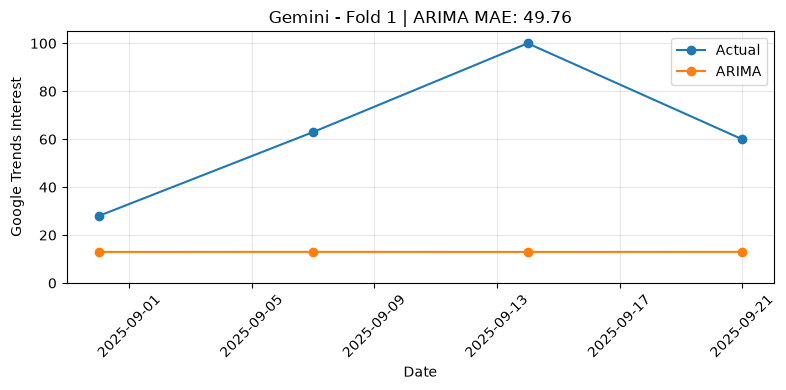

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:57 - cmdstanpy - INFO - Chain [1] start processing
12:59:57 - cmdstanpy - INFO - Chain [1] done processing


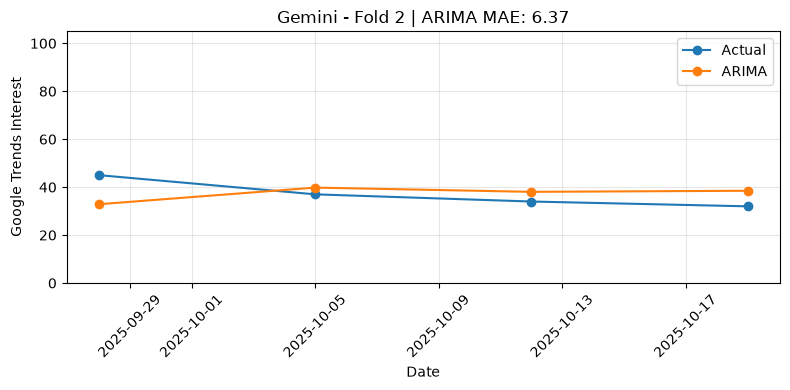

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:57 - cmdstanpy - INFO - Chain [1] start processing
12:59:57 - cmdstanpy - INFO - Chain [1] done processing


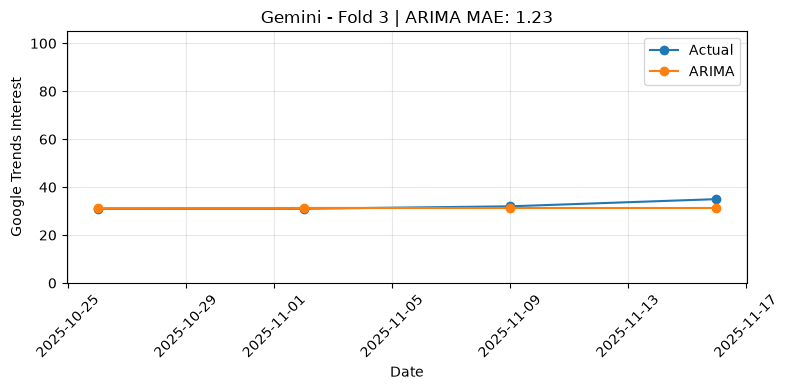

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:57 - cmdstanpy - INFO - Chain [1] start processing
12:59:57 - cmdstanpy - INFO - Chain [1] done processing


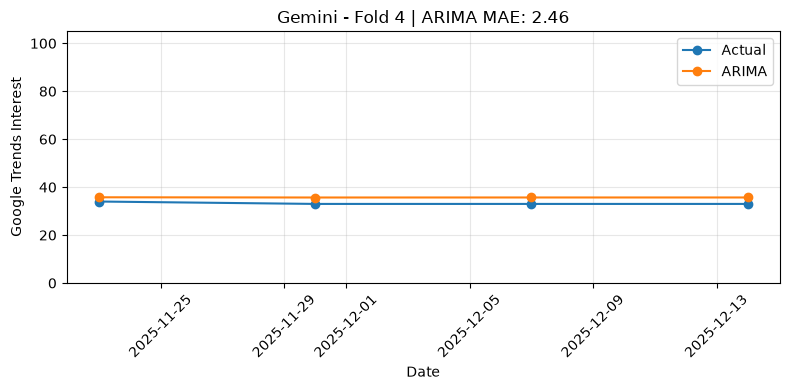

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:58 - cmdstanpy - INFO - Chain [1] start processing
12:59:58 - cmdstanpy - INFO - Chain [1] done processing


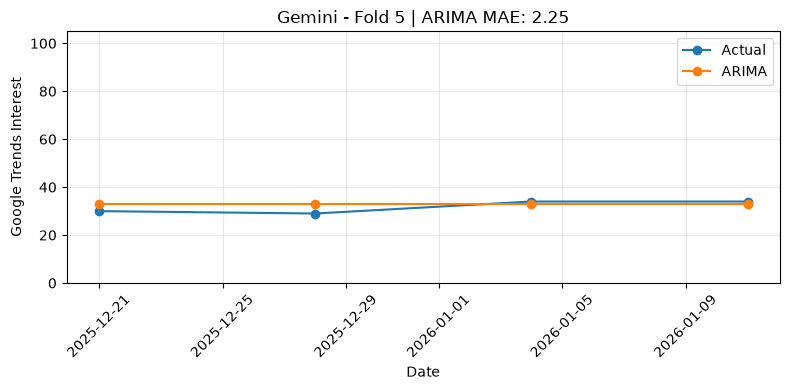

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:58 - cmdstanpy - INFO - Chain [1] start processing
12:59:58 - cmdstanpy - INFO - Chain [1] done processing


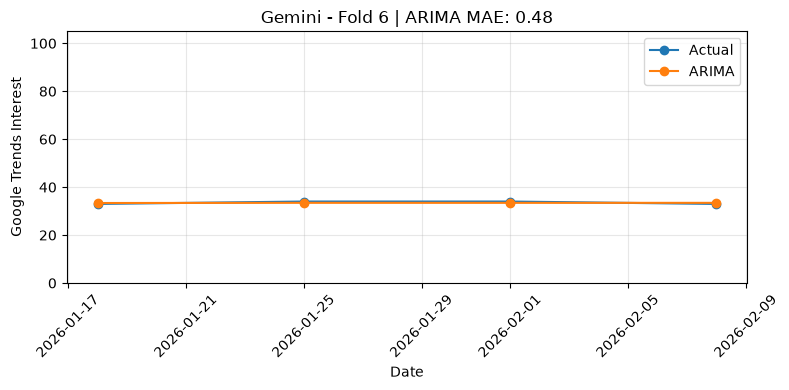

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:58 - cmdstanpy - INFO - Chain [1] start processing
12:59:58 - cmdstanpy - INFO - Chain [1] done processing


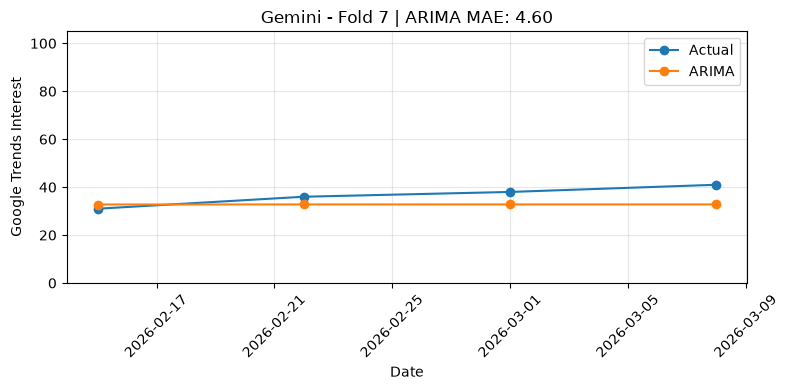

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:58 - cmdstanpy - INFO - Chain [1] start processing
12:59:58 - cmdstanpy - INFO - Chain [1] done processing


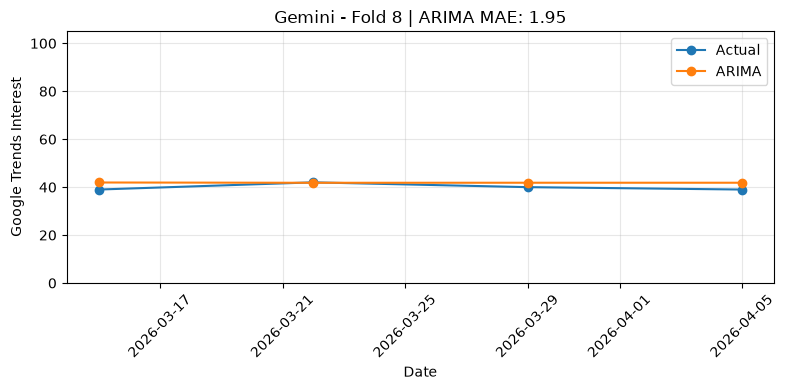

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:59 - cmdstanpy - INFO - Chain [1] start processing
12:59:59 - cmdstanpy - INFO - Chain [1] done processing


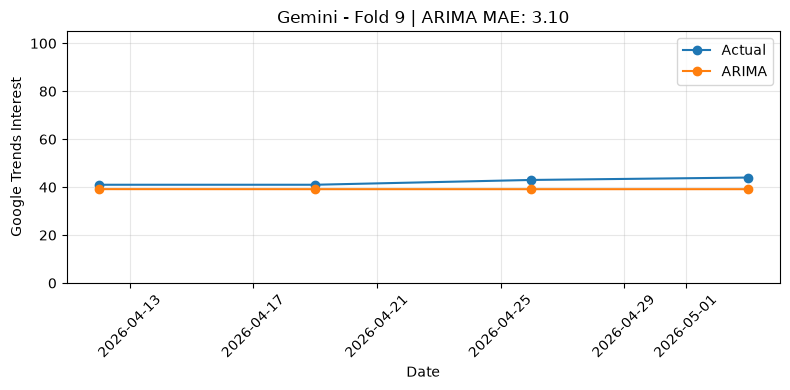

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:59 - cmdstanpy - INFO - Chain [1] start processing
12:59:59 - cmdstanpy - INFO - Chain [1] done processing


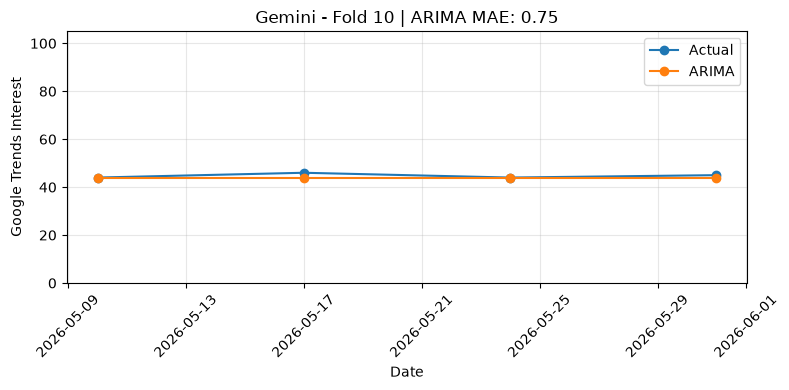

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:59 - cmdstanpy - INFO - Chain [1] start processing
12:59:59 - cmdstanpy - INFO - Chain [1] done processing


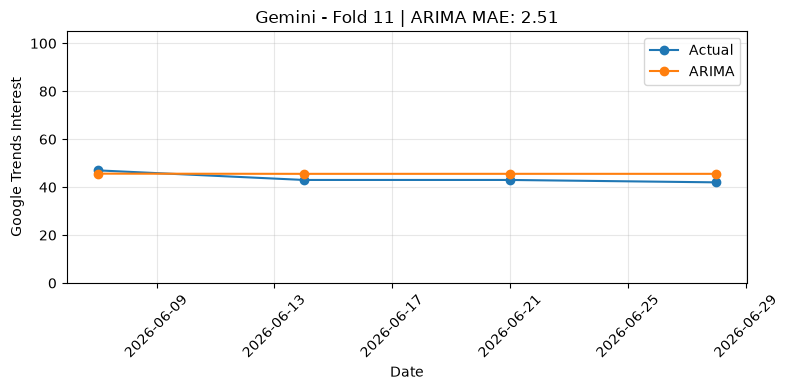

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
12:59:59 - cmdstanpy - INFO - Chain [1] start processing
12:59:59 - cmdstanpy - INFO - Chain [1] done processing


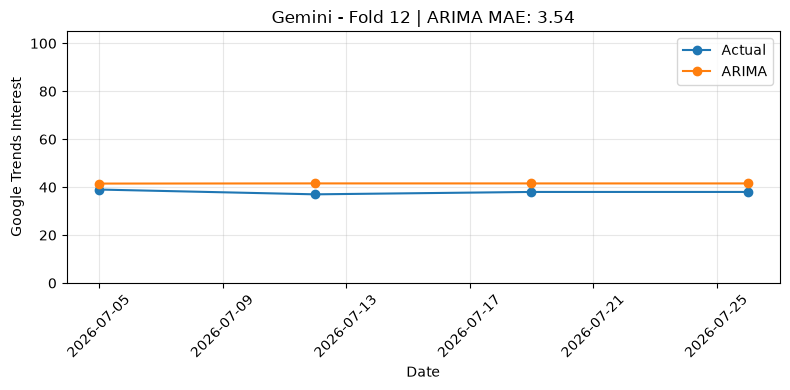

In [37]:
# --------------------------------------------------
# Gemini: Actual vs ARIMA tahminlerini fold fold çiz
# --------------------------------------------------

for fold_number in range(1, 13):

    # İlgili fold'un gerçek ve tahmin değerlerini al
    fold_predictions = get_gemini_fold_predictions(
        fold_number
    )

    actual = fold_predictions["Actual"]
    arima = fold_predictions["ARIMA"]


    # Fold'un MAE değerini hesapla
    fold_mae = mean_absolute_error(
        actual,
        arima,
    )


    # Yeni grafik oluştur
    plt.figure(figsize=(8, 4))


    # Gerçek değerleri çiz
    plt.plot(
        fold_predictions.index,
        actual,
        marker="o",
        label="Actual",
    )


    # ARIMA tahminlerini çiz
    plt.plot(
        fold_predictions.index,
        arima,
        marker="o",
        label="ARIMA",
    )


    # Grafik ayarları
    plt.title(
        f"Gemini - Fold {fold_number} | "
        f"ARIMA MAE: {fold_mae:.2f}"
    )

    plt.xlabel("Date")

    plt.ylabel("Google Trends Interest")

    # Google Trends ölçeği 0-100 olduğu için
    # bütün fold'larda aynı ekseni kullan
    plt.ylim(0, 105)

    plt.legend()

    plt.grid(alpha=0.3)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

### Spike Nedeni Araştırma

Evet, araştırınca **spike’ın sebebi büyük ölçüde ortaya çıkıyor: en güçlü aday “Nano Banana” olarak bilinen Gemini 2.5 Flash Image’ın viral olması.** Tarihler senin verinle şaşırtıcı derecede iyi örtüşüyor.

Google, yeni Gemini görüntü üretme/düzenleme modelini **26 Ağustos 2025’te** Gemini uygulamasında yayınladı. Model; fotoğraftaki kişinin görünüşünü koruyarak düzenleme, iki fotoğrafı birleştirme, kıyafet/stil değiştirme gibi özellikler getiriyordu. Google ve geliştirici bloglarında bunun Gemini 2.5 Flash Image, yani “Nano Banana” olduğu açıkça belirtiliyor. ([blog.google][1])

Senin veri:

```text
24 Ağustos   13
31 Ağustos   28
7 Eylül      63
14 Eylül    100   ← tepe
21 Eylül     60
28 Eylül     45
```

Nano Banana ise **26 Ağustos'ta** çıktı. Yani Google Trends değerinin `13 → 28` yükselmeye başladığı haftadan sadece birkaç gün önce. Bu zamanlama çok güçlü bir ipucu. ([blog.google][1])

Daha da önemlisi, gerçek kullanım verileri senin grafiğinle neredeyse aynı şekli gösteriyor. TechCrunch’ın Appfigures verilerine göre Hindistan’da Gemini’nin günlük indirmeleri **1 Eylül’de yaklaşık 55 bin iken 13 Eylül’de 414 bine** çıktı; yani yaklaşık **%667 artış** yaşandı. Gemini, 10 Eylül’den itibaren Hindistan iOS listesinde, 12 Eylül’den itibaren de Google Play’de zirveye çıktı. Haberde Gemini’nin küresel uygulama mağazası listelerinde de yükseldiği belirtiliyor. ([TechCrunch][2])

Şuna dikkat et:

```text
Senin Google Trends:
7 Eylül       63
14 Eylül     100  ← maksimum

Gemini indirmeleri:
1 Eylül      yükseliş başlıyor
10-12 Eylül uygulama listelerinde zirve
13 Eylül     indirme zirvesi
```

**Neredeyse tam aynı hafta.**

ABD’de de benzer bir durum olmuş: Gemini, Nano Banana sonrasında **8 Eylül’de App Store’da 2. sıraya**, **12 Eylül’de 1. sıraya** yükselmiş. Eylül ayının ilk yarısında Gemini’nin 12,6 milyon indirmeye ulaştığı ve indirmelerin önceki aya göre güçlü biçimde yükseldiği raporlanmış. ([TechCrunch][3])

Google da **12 Eylül’de**, Nano Banana ile dünya çapında o zamana kadar **500 milyondan fazla görsel üretildiğini** ve özelliğin sosyal medyada hızla yayıldığını yazmış. ([blog.google][4]) 19 Eylül’deki resmi Gemini güncellemesinde Google doğrudan Nano Banana’nın çok geniş ilgi gördüğünü belirtiyor. ([blog.google][5])

Dolayısıyla veri analisti olarak bence şöyle bir neden-sonuç hipotezi kurabiliriz:

```text
26 Ağustos
Nano Banana yayınlandı
        ↓
Sosyal medyada görsel düzenleme trendleri yayılmaya başladı
        ↓
Gemini'yi deneyen / arayan insan sayısı hızla arttı
        ↓
31 Ağustos haftası
Google Trends: 13 → 28
        ↓
7 Eylül
28 → 63
        ↓
10–13 Eylül
Gemini uygulama mağazalarında zirveye çıktı
Nano Banana viral hale geldi
        ↓
14 Eylül haftası
Google Trends = 100
```

Burada **“kesin %100 Nano Banana yüzünden oldu”** demek bilimsel açıdan fazla güçlü olur. Aynı dönemde Google, Gemini Live geliştirmeleri ve Pixel 10 ile ilgili Gemini özelliklerini de duyuruyordu; örneğin Gemini Live için yeni görsel yardım özellikleri 20 Ağustos’ta açıklanmış ve Pixel 10’da 28 Ağustos’tan itibaren sunulmaya başlanmıştı. Bunlar da ilgiyi bir miktar artırmış olabilir. ([blog.google][6]) Ancak Nano Banana’nın çıkış tarihi, viral kullanım verileri, uygulama indirme zirvesi ve senin Google Trends zirven **aynı 2–3 haftalık pencereye denk geldiği için ana açıklama olarak Nano Banana çok daha güçlü görünüyor.**

Bir de `100`ü doğru yorumlamamız önemli: bu **“100 arama” veya “%100 artış” değil**. Google Trends, seçilen zaman/coğrafya içindeki göreli ilgiyi `0–100` arasında normalize ediyor; `100`, sorgunun incelenen aralıktaki **en yüksek göreli ilgi noktası**. ([Google Destek][7])

Bu aslında Fold 1’de modelimizin neden çöktüğünü de çok güzel açıklıyor: ARIMA’nın elinde **26 Ağustos’ta yeni ve viral bir ürün özelliğinin çıkacağı bilgisi yoktu**. Önünde yalnızca geçmişteki:

```text
10 → 11 → 12 → 12 → 12 → 13
```

değerleri vardı. Bu yüzden `13` civarı tahmin etmesi matematiksel olarak anlaşılır; gerçek dünyadaki viral olay ise seriyi bir anda `28 → 63 → 100`e taşıdı.

Bu örnek final rapor için de çok değerli: **sadece geçmiş trend değerleriyle çalışan zaman serisi modellerinin, dışsal olayların neden olduğu ani ilgi patlamalarını önceden yakalamakta zorlanabileceğini** gerçek veri üzerinde göstermiş olduk.



## Claude Model Comparison

Bu bölümde aynı forecasting pipeline Claude Google Trends serisine uygulanacaktır.

Amaç, ChatGPT ve Gemini üzerinde kullanılan Naive, ARIMA, Prophet,
XGBoost ve Ensemble modellerinin Claude serisindeki performansını
aynı 12-fold ve 4 haftalık cross-validation yapısı altında karşılaştırmaktır.

In [38]:
# --------------------------------------------------
# Claude trend serisini seç
# --------------------------------------------------

claude = data["claude"]

N_LAGS = 8


# Bütün modelleri XGBoost ile aynı tarih aralığına hizala

aligned_claude = claude.iloc[N_LAGS:]


# Claude için cross-validation

tscv_claude = TimeSeriesSplit(
    n_splits=12,
    test_size=4,
)


print("Shape:", aligned_claude.shape)
print("İlk tarih:", aligned_claude.index[0])
print("Son tarih:", aligned_claude.index[-1])

Shape: (149,)
İlk tarih: 2023-09-24 00:00:00
Son tarih: 2026-07-26 00:00:00


In [39]:
# --------------------------------------------------
# Naive
# --------------------------------------------------

naive_claude = evaluate_naive_cv(
    series=aligned_claude,
    splitter=tscv_claude,
)


# --------------------------------------------------
# ARIMA
# --------------------------------------------------

arima_claude = evaluate_arima_cv(
    series=aligned_claude,
    splitter=tscv_claude,
    order=(1, 1, 1),
)


# --------------------------------------------------
# Prophet
# --------------------------------------------------

prophet_claude = evaluate_prophet_cv(
    series=aligned_claude,
    splitter=tscv_claude,
    changepoint_prior_scale=1.0,
    yearly_seasonality="auto",
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [40]:
# --------------------------------------------------
# Claude için 8 lag oluştur
# --------------------------------------------------

lag_data_claude = pd.DataFrame(
    {
        "target": claude,

        **{
            f"lag_{i}": claude.shift(i)
            for i in range(1, N_LAGS + 1)
        },
    }
)


# İlk 8 satırda lag'ler eksik olacağı için kaldır

lag_data_claude = lag_data_claude.dropna()


# --------------------------------------------------
# Son haftalardaki değişimleri ekle
# --------------------------------------------------

lag_data_claude["change_1"] = (
    lag_data_claude["lag_1"]
    - lag_data_claude["lag_2"]
)

lag_data_claude["change_2"] = (
    lag_data_claude["lag_2"]
    - lag_data_claude["lag_3"]
)


# --------------------------------------------------
# X = modele verdiğimiz bilgiler
# y = tahmin etmeye çalıştığımız gerçek değer
# --------------------------------------------------

X_claude = lag_data_claude[
    [
        *[
            f"lag_{i}"
            for i in range(1, N_LAGS + 1)
        ],
        "change_1",
        "change_2",
    ]
]

y_claude = lag_data_claude["target"]


print("X shape:", X_claude.shape)
print("y shape:", y_claude.shape)

X shape: (149, 10)
y shape: (149,)


In [41]:
# --------------------------------------------------
# XGBoost
# ChatGPT'te seçtiğimiz ayarları değiştirmeden kullanıyoruz
# --------------------------------------------------

xgb_claude = evaluate_xgb_recursive_with_change(
    X=X_claude,
    y=y_claude,
    splitter=tscv_claude,
)

In [42]:
# --------------------------------------------------
# Ensemble (%50 Prophet(auto) + %50 XGBoost)
# --------------------------------------------------

ensemble_claude = evaluate_ensemble_cv(
    series=aligned_claude,
    X=X_claude,
    y=y_claude,
    splitter=tscv_claude,
    prophet_weight=0.5,
    xgb_weight=0.5,
    yearly_seasonality="auto",
)

14:41:06 - cmdstanpy - INFO - Chain [1] start processing
14:41:06 - cmdstanpy - INFO - Chain [1] done processing
14:41:06 - cmdstanpy - INFO - Chain [1] start processing
14:41:06 - cmdstanpy - INFO - Chain [1] done processing
14:41:07 - cmdstanpy - INFO - Chain [1] start processing
14:41:07 - cmdstanpy - INFO - Chain [1] done processing
14:41:07 - cmdstanpy - INFO - Chain [1] start processing
14:41:07 - cmdstanpy - INFO - Chain [1] done processing
14:41:07 - cmdstanpy - INFO - Chain [1] start processing
14:41:07 - cmdstanpy - INFO - Chain [1] done processing
14:41:07 - cmdstanpy - INFO - Chain [1] start processing
14:41:07 - cmdstanpy - INFO - Chain [1] done processing
14:41:07 - cmdstanpy - INFO - Chain [1] start processing
14:41:07 - cmdstanpy - INFO - Chain [1] done processing
14:41:07 - cmdstanpy - INFO - Chain [1] start processing
14:41:08 - cmdstanpy - INFO - Chain [1] done processing
14:41:08 - cmdstanpy - INFO - Chain [1] start processing
14:41:08 - cmdstanpy - INFO - Chain [1]

In [43]:
# --------------------------------------------------
# Claude model karşılaştırması
# --------------------------------------------------

claude_comparison = pd.DataFrame(
    {
        "Mean MAE": [
            naive_claude["MAE"].mean(),
            arima_claude["MAE"].mean(),
            prophet_claude["MAE"].mean(),
            xgb_claude["MAE"].mean(),
            ensemble_claude["MAE"].mean(),
        ],

        "Median MAE": [
            naive_claude["MAE"].median(),
            arima_claude["MAE"].median(),
            prophet_claude["MAE"].median(),
            xgb_claude["MAE"].median(),
            ensemble_claude["MAE"].median(),
        ],

        "Std MAE": [
            naive_claude["MAE"].std(),
            arima_claude["MAE"].std(),
            prophet_claude["MAE"].std(),
            xgb_claude["MAE"].std(),
            ensemble_claude["MAE"].std(),
        ],

        "Mean RMSE": [
            naive_claude["RMSE"].mean(),
            arima_claude["RMSE"].mean(),
            prophet_claude["RMSE"].mean(),
            xgb_claude["RMSE"].mean(),
            ensemble_claude["RMSE"].mean(),
        ],
    },

    index=[
        "Naive",
        "ARIMA",
        "Prophet",
        "XGBoost",
        "Ensemble",
    ],
)


claude_comparison.sort_values(
    by="Mean MAE"
)

,Mean MAE,Median MAE,Std MAE,Mean RMSE
ARIMA,1.316729,1.041143,0.968111,1.535028
Prophet,1.415432,0.934142,1.169293,1.578472
Naive,1.437500,1.125000,0.971907,1.666558
Ensemble,1.491859,0.962533,1.142615,1.697531
XGBoost,1.700738,0.996841,1.162763,1.946459


Burada Claude tarafı **çok daha dengeli** görünüyor ve sonuçlar birbirine oldukça yakın:

```text
              Mean MAE   Median MAE   Std MAE   Mean RMSE
ARIMA           1.317       1.041       0.968      1.535
Prophet         1.415       0.934       1.169      1.578
Naive           1.438       1.125       0.972      1.667
Ensemble        1.492       0.963       1.143      1.698
XGBoost         1.701       0.997       1.163      1.946
```

Bunu tane tane okuyalım:

**Genel performans → ARIMA kazanıyor.** `Mean MAE = 1.317` ve `Mean RMSE = 1.535` ile ikisinde de en düşük hata onda. Yani 12 fold’un tamamını birlikte düşündüğümüzde en güvenilir aday şu anda ARIMA.

**Tipik bir fold → Prophet çok az farkla kazanıyor.**

```text
Median MAE
Prophet  = 0.934
Ensemble = 0.963
XGBoost  = 0.997
ARIMA    = 1.041
```

Bu bize şunu söylüyor: sıradan bir 4 haftalık dönemde Prophet çok iyi davranabiliyor. Ama bazı dönemlerde yaptığı daha büyük hatalar mean’i `1.415`e çıkarıyor.

**Stabilite → ARIMA ve Naive önde.**

```text
ARIMA std = 0.968
Naive std = 0.972
```

Neredeyse aynı. Yani hata miktarları fold’dan fold’a diğer modellere göre daha az değişiyor.

Bir de önemli sonuç: **Ensemble burada fayda sağlamadı.**

```text
Prophet  = 1.415
XGBoost  = 1.701
Ensemble = 1.492
```

Ensemble XGBoost’u düzeltiyor ama Prophet’i ve ARIMA’yı geçemiyor. Bu da ChatGPT’te işe yarayan `Prophet + XGBoost` birleşiminin her seride otomatik olarak avantaj sağlamadığını tekrar gösteriyor.

Claude’da Naive’ın `1.438` gibi güçlü olması da önemli. Basit “son değere yakın devam et” yaklaşımı bile iyi çalışıyor. Bu, Claude trend değerlerinin test ettiğimiz dönemlerin çoğunda haftadan haftaya çok sert değişmemiş olabileceğini düşündürüyor.

Ama **“Claude kesin Gemini’den çok daha kolay tahmin ediliyor”** demeden önce dikkatli olalım. Claude’un Google Trends değerlerinin genel seviyesi Gemini/ChatGPT’den daha düşükse, mutlak MAE’nin de doğal olarak daha düşük olması mümkün. Yani `1.3 vs 6.5` karşılaştırmasını tek başına zorluk karşılaştırması olarak kullanmayalım.

Şimdi bence Gemini’de yaptığımız gibi **fold tablosunu çıkaralım**. Böylece ARIMA neden mean’de kazanırken Prophet median’da kazanıyor anlayacağız:

 özellikle **Prophet’in hangi fold’larda mean’ini yukarı çeken hata yaptığını** bulalım.


In [44]:


# --------------------------------------------------
# Claude modellerini fold bazında karşılaştır
# --------------------------------------------------

claude_fold_comparison = pd.DataFrame(
    {
        "Fold": list(range(1, 13)),
        "Naive": naive_claude["MAE"],
        "ARIMA": arima_claude["MAE"],
        "Prophet": prophet_claude["MAE"],
        "XGBoost": xgb_claude["MAE"],
        "Ensemble": ensemble_claude["MAE"],
    }
)

claude_fold_comparison


,Fold,Naive,ARIMA,Prophet,XGBoost,Ensemble
0,1,1.00,0.750788,0.926249,1.046075,0.986162
1,2,1.00,0.834580,0.281876,0.947607,0.614742
2,3,0.00,0.216552,0.185892,0.840560,0.513226
3,4,0.50,0.508545,0.500450,0.783793,0.583385
4,5,0.75,0.779912,0.769547,0.904151,0.836849
5,6,1.25,2.093835,2.539108,2.689172,2.614140
6,7,3.50,3.822207,3.986630,4.034738,4.010684
7,8,2.50,1.134657,1.275765,2.714811,1.522980
8,9,2.25,1.576681,2.063252,1.458868,1.648712
9,10,1.50,1.082283,0.762516,0.732021,0.595954


Bu tablo Claude’da gerçekten daha “normal” bir dağılım olduğunu gösteriyor. Gemini’deki gibi tek bir fold gelip her şeyi 50 MAE’ye taşımıyor.

En dikkat çekici yerler:

```text
Fold 1–5
hatalar çoğunlukla 0–1 civarı

Fold 6–7
bütün modeller belirgin şekilde zorlanıyor

Fold 8–11
yeniden toparlanıyorlar

Fold 12
özellikle Prophet/XGBoost/Ensemble tekrar kötüleşiyor
```

Buradan şu çıkarımı yapabiliriz:

> Claude serisinde belirli birkaç zor dönem var ama Gemini’deki kadar uç bir ani patlama yok. Bu yüzden mean ile median arasındaki fark da çok daha küçük.

ARIMA’nın mean’de neden birinci olduğuna da bakınca mantık oturuyor. Mesela Fold 8:

```text
Naive    2.50
ARIMA    1.13   ← çok iyi
Prophet  1.28
XGBoost  2.71
```

Fold 9:

```text
Naive    2.25
ARIMA    1.58
Prophet  2.06
XGBoost  1.46
```

ARIMA birçok zor dönemde “çok kötüye düşmeden” makul kalıyor.

Prophet ise bazı fold’larda inanılmaz iyi:

```text
Fold 2 → 0.28
Fold 3 → 0.19
Fold 10 → 0.76
```

Bu yüzden medianı en düşük. Ama Fold 6, 7, 12 gibi yerlerde:

```text
2.54
3.99
2.75
```

gibi daha büyük hatalar yaptığı için mean’de ARIMA’nın arkasına düşüyor.

XGBoost da benzer ama biraz daha sert:

```text
Fold 7  → 4.03
Fold 12 → 3.32
```

Bu da neden genel mean’inin en yüksek olduğunu açıklıyor.

şimdi burada da “winner” çıkaralım; hangi model kaç fold kazanmış görelim:

Sonra Claude için final yorumu çok daha sağlam yazabiliriz. Özellikle şunu merak ediyorum: **Prophet median’da öndeyken aslında kaç fold kazanmış?**


In [45]:

claude_fold_comparison["Winner"] = claude_fold_comparison[
    ["Naive", "ARIMA", "Prophet", "XGBoost", "Ensemble"]
].idxmin(axis=1)

claude_fold_comparison["Winner"].value_counts()



Winner
Naive       6
ARIMA       2
XGBoost     2
Prophet     1
Ensemble    1
Name: count, dtype: int64

Evet, işte burada çok güzel bir veri analizi dersi çıkıyor:

```text
Fold galibiyetleri
Naive       6
ARIMA       2
XGBoost     2
Prophet     1
Ensemble    1
```

İlk bakışta “O zaman en iyi model Naive değil mi?” diye düşündürüyor. Ama **hayır; çünkü winner sayısı ile genel hata aynı şeyi ölçmüyor.**

Naive’ın 6 galibiyetinin bir kısmı inanılmaz küçük farklarla geliyor. Örneğin:

```text
Fold 4
Naive    = 0.500000
Prophet  = 0.500450
```

Naive kazandı ama fark sadece `0.00045`.

Fold 5:

```text
Naive    = 0.750
Prophet  = 0.770
ARIMA    = 0.780
```

Yine kazanıyor ama fark küçük.

Fold 12:

```text
Naive = 2.000000
ARIMA = 2.000706
```

Neredeyse beraberler ama winner sütununda yalnızca **Naive** yazıyor.

Yani `Winner = Naive` demek:

> “Bu fold’da diğerlerinden mutlaka çok daha iyiydi.”

demek değil. Sadece **en küçük sayı ona ait** demek.

ARIMA'nın farkı ise şu: yalnızca 2 fold kazanıyor ama birçok fold’da ya birinciye çok yakın ya da özellikle zor dönemlerde güçlü kalıyor. Mesela Fold 8:

```text
Naive    = 2.50
ARIMA    = 1.13
Prophet  = 1.28
XGBoost  = 2.71
```

Burada ARIMA'nın kazancı bayağı büyük. Bu tür büyük avantajlar ortalama MAE’yi aşağı çekiyor.

Bu yüzden:

```text
                 Kazandığı fold     Mean MAE
Naive                  6              1.438
ARIMA                  2              1.317  ← daha iyi
```

olabiliyor.

Prophet’in durumu da ayrı ilginç. Sadece **1 fold kazanıyor**, ama median MAE’si en iyi:

```text
Prophet median = 0.934
ARIMA median   = 1.041
Naive median   = 1.125
```

Çünkü median “kaç kez birinci oldun?” diye sormuyor. Şunu soruyor:

> “Senin kendi 12 hata değerini küçükten büyüğe dizersek, ortadaki tipik hatan ne?”

Prophet birçok fold’da **birinci olmayıp yine de oldukça düşük hata** yapabiliyor. Mesela ikinci veya üçüncü olabilir ama `0.8–1.0` civarında kalabilir. Bu yüzden tipik performansı çok iyi görünüyor.

Claude için şu anki genel tabloyu ben şöyle okurum:

> **Naive en sık kazanan model, Prophet tipik bir dönemde en düşük hataya sahip model, ARIMA ise 12 dönemin tamamındaki hata büyüklüklerini hesaba kattığımızda en iyi genel performansı veren model.**

Ve model seçecek olsaydık, mevcut sonuçlarla **ARIMA’yı ana aday yapardım**. Çünkü hem Mean MAE hem Mean RMSE en düşük, standart sapması da en düşük seviyelerden biri. Naive’ın 6 fold kazanması ise bize Claude serisinin birçok dönemde “son değere yakın devam etme” yöntemiyle bile iyi tahmin edilebildiğini söylüyor.

Bence şimdi bunu notebook’a kısa bir sonuç Markdown’ı olarak koyup, ardından **ChatGPT–Gemini–Claude sonuçlarını tek bir final tabloda karşılaştıralım.** Bu üç seri arasındaki fark projenin çok güzel bir ana sonucu olur.


### Claude Model Comparison — Final Evaluation

Claude trend serisi, diğer serilerle aynı olacak şekilde `12-fold` ve her fold için `4 haftalık` tahmin dönemi kullanılarak değerlendirilmiştir.

Genel sonuçlarda **ARIMA**, en düşük ortalama MAE (`1.317`) ve RMSE (`1.535`) değerlerini elde ederek en güçlü genel model olmuştur. Ayrıca MAE standart sapmasının düşük olması, performansının fold'lar arasında daha dengeli kaldığını göstermektedir.

**Prophet**, en düşük median MAE (`0.934`) değerine sahiptir. Bu sonuç, tipik bir tahmin döneminde Prophet'in oldukça başarılı olabildiğini; ancak bazı zor fold'lardaki daha yüksek hataların genel ortalamasını yükselttiğini göstermektedir.

Naive model 12 fold'un **6'sında en düşük MAE'yi** elde ederek en fazla fold kazanan model olmuştur. Ancak bu galibiyetlerin bir kısmında diğer modellerle arasındaki fark oldukça küçüktür. Bu nedenle yalnızca fold kazanma sayısına göre model seçmek yerine ortalama hata büyüklüklerinin de değerlendirilmesi gerekmektedir.

XGBoost ve Prophet + XGBoost Ensemble modelleri Claude serisinde ek bir genel avantaj sağlamamıştır. Ensemble, XGBoost'un hatasını azaltmasına rağmen ARIMA ve Prophet modellerini geçememiştir.

Sonuç olarak Claude serisi için mevcut cross-validation sonuçlarına göre **ARIMA ana model adayıdır**. Bununla birlikte Naive modelinin birçok fold'da güçlü performans göstermesi, Claude trend serisinin bazı dönemlerde önceki değere yakın hareket ettiğini düşündürmektedir.


#### ChatGPT' nin trend analizlerini tekrar alalım

In [48]:
# --------------------------------------------------
# ChatGPT - Final standardized evaluation
# --------------------------------------------------

chatgpt = data["chatgpt"]

N_LAGS = 8

aligned_chatgpt = chatgpt.iloc[N_LAGS:]


tscv_chatgpt = TimeSeriesSplit(
    n_splits=12,
    test_size=4,
)


# --------------------------------------------------
# Naive
# --------------------------------------------------

naive_chatgpt = evaluate_naive_cv(
    series=aligned_chatgpt,
    splitter=tscv_chatgpt,
)


# --------------------------------------------------
# ARIMA
# --------------------------------------------------

arima_chatgpt = evaluate_arima_cv(
    series=aligned_chatgpt,
    splitter=tscv_chatgpt,
    order=(1, 1, 1),
)


# --------------------------------------------------
# Prophet
# --------------------------------------------------

prophet_chatgpt = evaluate_prophet_cv(
    series=aligned_chatgpt,
    splitter=tscv_chatgpt,
    changepoint_prior_scale=1.0,
    yearly_seasonality="auto",
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [49]:
# --------------------------------------------------
# ChatGPT - XGBoost features
# --------------------------------------------------

lag_data_chatgpt = pd.DataFrame(
    {
        "target": chatgpt,

        **{
            f"lag_{i}": chatgpt.shift(i)
            for i in range(1, N_LAGS + 1)
        },
    }
).dropna()


lag_data_chatgpt["change_1"] = (
    lag_data_chatgpt["lag_1"]
    - lag_data_chatgpt["lag_2"]
)

lag_data_chatgpt["change_2"] = (
    lag_data_chatgpt["lag_2"]
    - lag_data_chatgpt["lag_3"]
)


X_chatgpt = lag_data_chatgpt[
    [
        *[
            f"lag_{i}"
            for i in range(1, N_LAGS + 1)
        ],
        "change_1",
        "change_2",
    ]
]

y_chatgpt = lag_data_chatgpt["target"]

In [50]:
# --------------------------------------------------
# XGBoost
# --------------------------------------------------

xgb_chatgpt = evaluate_xgb_recursive_with_change(
    X=X_chatgpt,
    y=y_chatgpt,
    splitter=tscv_chatgpt,
)


# --------------------------------------------------
# Ensemble
# --------------------------------------------------

ensemble_chatgpt = evaluate_ensemble_cv(
    series=aligned_chatgpt,
    X=X_chatgpt,
    y=y_chatgpt,
    splitter=tscv_chatgpt,
    prophet_weight=0.5,
    xgb_weight=0.5,
    yearly_seasonality="auto",
)

15:57:37 - cmdstanpy - INFO - Chain [1] start processing
15:57:37 - cmdstanpy - INFO - Chain [1] done processing
15:57:37 - cmdstanpy - INFO - Chain [1] start processing
15:57:37 - cmdstanpy - INFO - Chain [1] done processing
15:57:38 - cmdstanpy - INFO - Chain [1] start processing
15:57:38 - cmdstanpy - INFO - Chain [1] done processing
15:57:38 - cmdstanpy - INFO - Chain [1] start processing
15:57:38 - cmdstanpy - INFO - Chain [1] done processing
15:57:38 - cmdstanpy - INFO - Chain [1] start processing
15:57:38 - cmdstanpy - INFO - Chain [1] done processing
15:57:38 - cmdstanpy - INFO - Chain [1] start processing
15:57:38 - cmdstanpy - INFO - Chain [1] done processing
15:57:38 - cmdstanpy - INFO - Chain [1] start processing
15:57:38 - cmdstanpy - INFO - Chain [1] done processing
15:57:39 - cmdstanpy - INFO - Chain [1] start processing
15:57:39 - cmdstanpy - INFO - Chain [1] done processing
15:57:39 - cmdstanpy - INFO - Chain [1] start processing
15:57:39 - cmdstanpy - INFO - Chain [1]

In [51]:
print("Naive:", naive_chatgpt["MAE"].mean())
print("ARIMA:", arima_chatgpt["MAE"].mean())
print("Prophet:", prophet_chatgpt["MAE"].mean())
print("XGBoost:", xgb_chatgpt["MAE"].mean())
print("Ensemble:", ensemble_chatgpt["MAE"].mean())

Naive: 4.541666666666667
ARIMA: 4.413942245524211
Prophet: 4.2352218319617565
XGBoost: 4.355783621470134
Ensemble: 3.911401565392208


## Model Comparison for all AI's

In [52]:
# --------------------------------------------------
# FINAL MODEL COMPARISON
# ChatGPT - Gemini - Claude
# --------------------------------------------------

final_mae_comparison = pd.DataFrame(
    {
        "Naive": [
            naive_chatgpt["MAE"].mean(),
            naive_gemini["MAE"].mean(),
            naive_claude["MAE"].mean(),
        ],

        "ARIMA": [
            arima_chatgpt["MAE"].mean(),
            arima_gemini["MAE"].mean(),
            arima_claude["MAE"].mean(),
        ],

        "Prophet": [
            prophet_chatgpt["MAE"].mean(),
            prophet_gemini_auto["MAE"].mean(),
            prophet_claude["MAE"].mean(),
        ],

        "XGBoost": [
            xgb_chatgpt["MAE"].mean(),
            xgb_gemini["MAE"].mean(),
            xgb_claude["MAE"].mean(),
        ],

        "Ensemble": [
            ensemble_chatgpt["MAE"].mean(),
            ensemble_gemini_auto["MAE"].mean(),
            ensemble_claude["MAE"].mean(),
        ],
    },

    index=[
        "ChatGPT",
        "Gemini",
        "Claude",
    ],
)


final_mae_comparison.round(3)

,Naive,ARIMA,Prophet,XGBoost,Ensemble
ChatGPT,4.542,4.414,4.235,4.356,3.911
Gemini,7.896,6.582,8.969,10.884,9.577
Claude,1.438,1.317,1.415,1.701,1.492


her seri için kazananı otomatik ekleyelim:

In [53]:
final_mae_comparison["Best Model"] = (
    final_mae_comparison[
        [
            "Naive",
            "ARIMA",
            "Prophet",
            "XGBoost",
            "Ensemble",
        ]
    ].idxmin(axis=1)
)


final_mae_comparison.round(3)

,Naive,ARIMA,Prophet,XGBoost,Ensemble,Best Model
ChatGPT,4.542,4.414,4.235,4.356,3.911,Ensemble
Gemini,7.896,6.582,8.969,10.884,9.577,ARIMA
Claude,1.438,1.317,1.415,1.701,1.492,ARIMA


## Final Model Comparison

ChatGPT, Gemini ve Claude trend serileri aynı time-series cross-validation
yapısı altında Naive, ARIMA, Prophet, XGBoost ve Ensemble modelleri ile
karşılaştırılmıştır.

Sonuçlar, tek bir forecasting modelinin tüm trend serilerinde en iyi
performansı göstermediğini ortaya koymuştur.

- ChatGPT serisinde en iyi tekil model Prophet olurken, Prophet ve XGBoost
  tahminlerinin birleştirildiği Ensemble yaklaşımı en düşük Mean MAE
  değerini elde etmiştir.

- Gemini serisinde ARIMA en düşük Mean MAE değerine ulaşmıştır. Özellikle
  ani ve dışsal bir olayla ilişkili büyük trend artışlarında tüm modellerin
  zorlandığı görülmüştür.

- Claude serisinde de ARIMA en düşük Mean MAE ve Mean RMSE değerlerini elde
  ederek genel olarak en başarılı model olmuştur.

Bu sonuçlar, farklı trend serilerinin farklı zaman serisi davranışlarına
sahip olduğunu ve tek bir modelin tüm serilere zorlanması yerine, her seri
için cross-validation performansına göre model seçilmesinin daha uygun
olabileceğini göstermektedir.

Şimdi yapacağımız ilk şey yeni model geliştirmek değil. Elimizdeki sonucu gerçek bir “tahmin motoruna” çevireceğiz.

Mesela kullanıcı chatgpt seçtiğinde sistemin şunu yapmasını istiyoruz:

chatgpt
   ↓
CV sonuçlarına bak
   ↓
Ensemble en iyi
   ↓
Ensemble seç
   ↓
gelecek 4 haftayı tahmin et

Gemini için:

gemini
   ↓
ARIMA en iyi
   ↓
ARIMA seç
   ↓
gelecek 4 haftayı tahmin et. Bunu forecasting.py' a ekledik.

In [56]:
import importlib
import src.forecasting

importlib.reload(src.forecasting)

<module 'src.forecasting' from '/Users/nihalapple/Desktop/trend-forecast-project/notebooks/../src/forecasting.py'>

In [58]:
from src.forecasting import select_best_model

In [59]:
#Şimdi önce ChatGPT ile test edelim:

chatgpt_results = {
    "Naive": naive_chatgpt,
    "ARIMA": arima_chatgpt,
    "Prophet": prophet_chatgpt,
    "XGBoost": xgb_chatgpt,
    "Ensemble": ensemble_chatgpt,
}


best_chatgpt_model, chatgpt_model_comparison = (
    select_best_model(chatgpt_results)
)


print("Best model:", best_chatgpt_model)

chatgpt_model_comparison

Best model: Ensemble


,Model,Mean_MAE,Mean_RMSE
0,Ensemble,3.911402,4.519721
1,Prophet,4.235222,4.783675
2,XGBoost,4.355784,4.901813
3,ARIMA,4.413942,5.000169
4,Naive,4.541667,5.241398


In [60]:
# --------------------------------------------------
# Gemini - Best Model Selection
# --------------------------------------------------

gemini_results = {
    "Naive": naive_gemini,
    "ARIMA": arima_gemini,
    "Prophet": prophet_gemini_auto,
    "XGBoost": xgb_gemini,
    "Ensemble": ensemble_gemini_auto,
}


best_gemini_model, gemini_model_comparison = (
    select_best_model(gemini_results)
)


print("Best Gemini model:", best_gemini_model)

gemini_model_comparison

Best Gemini model: ARIMA


,Model,Mean_MAE,Mean_RMSE
0,ARIMA,6.582279,7.402561
1,Naive,7.895833,8.650291
2,Prophet,8.968515,9.874318
3,Ensemble,9.576916,10.444926
4,XGBoost,10.883868,11.870638


In [61]:
# --------------------------------------------------
# Claude - Best Model Selection
# --------------------------------------------------

claude_results = {
    "Naive": naive_claude,
    "ARIMA": arima_claude,
    "Prophet": prophet_claude,
    "XGBoost": xgb_claude,
    "Ensemble": ensemble_claude,
}


best_claude_model, claude_model_comparison = (
    select_best_model(claude_results)
)


print("Best Claude model:", best_claude_model)

claude_model_comparison

Best Claude model: ARIMA


,Model,Mean_MAE,Mean_RMSE
0,ARIMA,1.316729,1.535028
1,Prophet,1.415432,1.578472
2,Naive,1.437500,1.666558
3,Ensemble,1.491859,1.697531
4,XGBoost,1.700738,1.946459


## Gerçek Gelecek Tahminleri

CV sırasında:
train → geçmişin bir kısmı
test  → geçmişteki sonraki 4 hafta

Şimdi:
train → elimizdeki TÜM veri
test  → yok

model → henüz gözlemlemediğimiz sonraki 4 haftayı tahmin ediyor

Yani artık gerçekten:

2026-07-26  ← son bildiğimiz hafta
     ↓
2026-08-02
2026-08-09
2026-08-16
2026-08-23

gibi geleceğe gidiyoruz.

In [63]:
from src.forecasting import forecast_arima

In [66]:
import inspect

print(inspect.signature(forecast_arima))

(series: pandas.Series, order: tuple[int, int, int], steps: int) -> pandas.Series


### Gemini ve Claude ARIMA Gelecek Tahminleri

In [67]:
FORECAST_WEEKS = 4

gemini_future = forecast_arima(
    series=gemini,
    order=(1, 1, 1),
    steps=FORECAST_WEEKS,
)

claude_future = forecast_arima(
    series=claude,
    order=(1, 1, 1),
    steps=FORECAST_WEEKS,
)

print("Gemini Forecast")
display(gemini_future)

print("Claude Forecast")
display(claude_future)

Gemini Forecast


/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

2026-08-02    37.824669
2026-08-09    37.848896
2026-08-16    37.845548
2026-08-23    37.846011
Freq: W-SUN, Name: predicted_mean, dtype: float64

Claude Forecast


2026-08-02    15.999439
2026-08-09    15.999473
2026-08-16    15.999471
2026-08-23    15.999471
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [68]:
import importlib
import src.forecasting

importlib.reload(src.forecasting)

from src.forecasting import forecast_xgb_recursive_with_change

### ChatGPT XGB Gelecek Tahmini

In [69]:
chatgpt_xgb_future = forecast_xgb_recursive_with_change(
    series=chatgpt,
    steps=FORECAST_WEEKS,
)

chatgpt_xgb_future

2026-08-02    67.729713
2026-08-09    69.413536
2026-08-16    70.815254
2026-08-23    71.216957
Freq: W-SUN, Name: xgb_forecast, dtype: float32

In [70]:
import importlib
import src.forecasting

importlib.reload(src.forecasting)

from src.forecasting import forecast_prophet

### ChatGPT Prophet Gelecek Tahmini

In [71]:
chatgpt_prophet_future = forecast_prophet(
    series=chatgpt,
    steps=FORECAST_WEEKS,
    changepoint_prior_scale=1.0,
    yearly_seasonality="auto",
)

chatgpt_prophet_future

16:36:14 - cmdstanpy - INFO - Chain [1] start processing
16:36:14 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
157,2026-08-02,66.628359,62.583446,70.360565
158,2026-08-09,66.554096,62.532634,70.625506
159,2026-08-16,67.394821,63.744504,71.127357
160,2026-08-23,68.953368,64.768775,72.748822


### ChatGPT Ensembled Tahmini

In [72]:
# --------------------------------------------------
# ChatGPT Final Ensemble Forecast
# Prophet %50 + XGBoost %50
# --------------------------------------------------

chatgpt_ensemble_future = pd.DataFrame(
    {
        "date": chatgpt_prophet_future["ds"].values,

        "Prophet": chatgpt_prophet_future["yhat"].values,

        "XGBoost": chatgpt_xgb_future.values,
    }
)


chatgpt_ensemble_future["Ensemble"] = (
    0.5 * chatgpt_ensemble_future["Prophet"]
    + 0.5 * chatgpt_ensemble_future["XGBoost"]
)


chatgpt_ensemble_future

,date,Prophet,XGBoost,Ensemble
0,2026-08-02,66.628359,67.729713,67.179036
1,2026-08-09,66.554096,69.413536,67.983816
2,2026-08-16,67.394821,70.815254,69.105038
3,2026-08-23,68.953368,71.216957,70.085163


## Tüm Gelecek Tahminleri

In [73]:
# --------------------------------------------------
# FINAL FORECAST TABLE
# ChatGPT - Gemini - Claude
# --------------------------------------------------

final_forecast = pd.DataFrame(
    {
        "Date": chatgpt_ensemble_future["date"].values,

        "ChatGPT": chatgpt_ensemble_future["Ensemble"].values,

        "Gemini": gemini_future.values,

        "Claude": claude_future.values,
    }
)


final_forecast

,Date,ChatGPT,Gemini,Claude
0,2026-08-02,67.179036,37.824669,15.999439
1,2026-08-09,67.983816,37.848896,15.999473
2,2026-08-16,69.105038,37.845548,15.999471
3,2026-08-23,70.085163,37.846011,15.999471


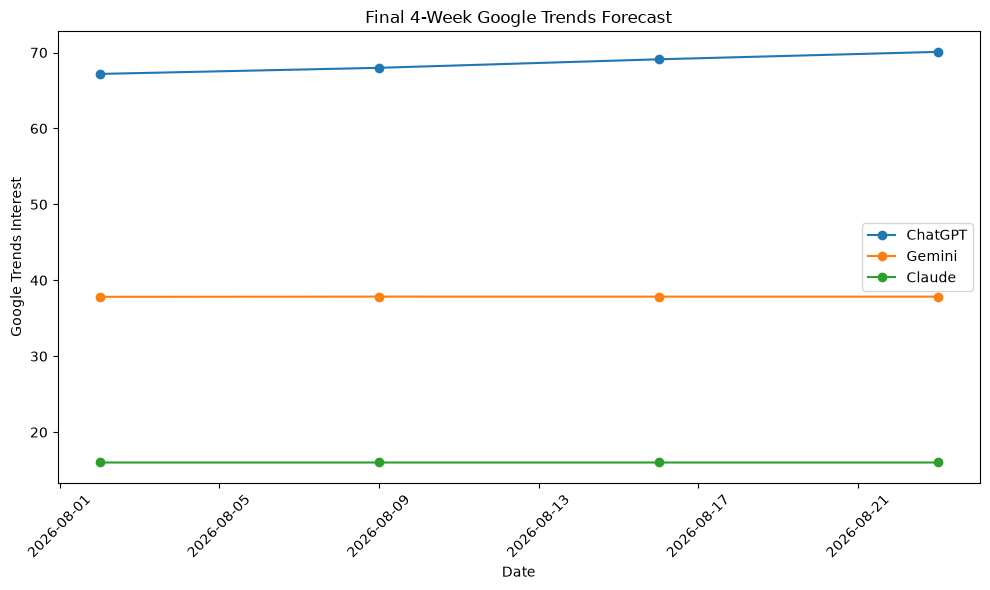

In [74]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.plot(
    final_forecast["Date"],
    final_forecast["ChatGPT"],
    marker="o",
    label="ChatGPT",
)

plt.plot(
    final_forecast["Date"],
    final_forecast["Gemini"],
    marker="o",
    label="Gemini",
)

plt.plot(
    final_forecast["Date"],
    final_forecast["Claude"],
    marker="o",
    label="Claude",
)


plt.title("Final 4-Week Google Trends Forecast")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

dosyayı "26 Temmuz 2026’ya kadar bilinen verilerle oluşturulan forecast" olrak kaydedelim sonra kontrol edicez.

In [75]:
# Son gözlem tarihini dosya adına ekle

data_cutoff = chatgpt.index[-1].strftime("%Y-%m-%d")

file_name = (
    f"../reports/final_forecast_as_of_{data_cutoff}.csv"
)

final_forecast.to_csv(
    file_name,
    index=False,
)

print("Saved:", file_name)

Saved: ../reports/final_forecast_as_of_2026-07-26.csv
